/tmp/ipython-input-1922638945.py:247: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


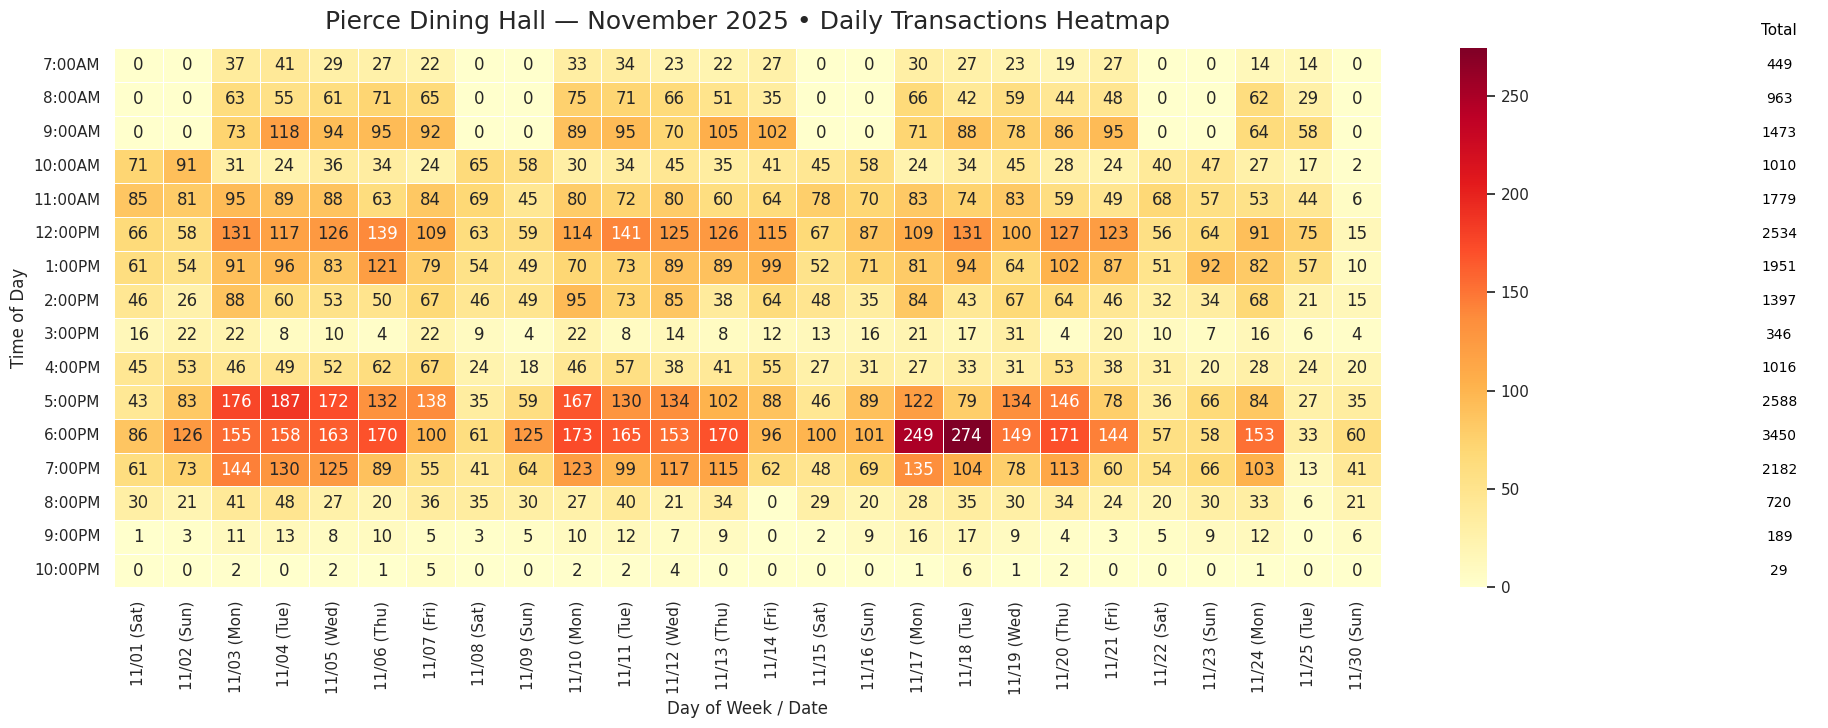

✅ Saved tidy data to: Pierce_Nov_2025_tidy.xlsx
✅ Saved heatmap image to: Pierce_Nov_2025_heatmap.png


In [ ]:
# this code turs  the data into long form
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from openpyxl import load_workbook
from matplotlib.patches import Rectangle

# ==================== CONFIG ====================
INPUT_XLSX = "/content/2026 today Daily Transactions November 2025.xlsx"   # <-- change to your file
SHEET_NAME = None  # None = active sheet, or e.g. "Sheet1"

DEFAULT_YEAR = 2025
TITLE = "Pierce Dining Hall — November 2025 • Daily Transactions Heatmap"

OUTPUT_TIDY_XLSX = "Pierce_Nov_2025_tidy.xlsx"
OUTPUT_PNG = "Pierce_Nov_2025_heatmap.png"

# Keep only these times (set None to keep all detected times)
KEEP_TIMES = None
# Example:
# KEEP_TIMES = ["7:00AM","8:00AM","9:00AM","10:00AM","11:00AM","12:00PM","1:00PM","2:00PM","3:00PM","4:00PM",
#               "5:00PM","6:00PM","7:00PM","8:00PM","9:00PM","10:00PM","11:00PM"]

# Drop times/days that are all zeros?
DROP_ALL_ZERO_DAYS = True
DROP_ALL_ZERO_TIMES = True

# BUT: always keep these times even if they are all zeros
ALWAYS_KEEP_TIMES = {"11:00AM"}  # add "11:00PM" if you want: {"11:00AM","11:00PM"}

ANNOTATE = True
CMAP = "YlOrRd"

# ==================== REGEX + HELPERS ====================
DOW_PATTERN = r"(MONDAY|TUESDAY|WEDNESDAY|THURSDAY|FRIDAY|SATURDAY|SUNDAY)"
HEADER_RE = re.compile(rf"^\s*{DOW_PATTERN}\s+(\d{{1,2}}/\d{{1,2}})(?:/\d{{2,4}})?\s*$", re.I)
TIME_RE = re.compile(r"^\s*(\d{1,2}):(\d{2})\s*(AM|PM)\s*$", re.I)

def normalize_time_str(s: str) -> str:
    """Normalize time like '7:00am' -> '7:00AM'."""
    s = str(s).strip()
    m = TIME_RE.match(s)
    if not m:
        return s
    hh, mm, ap = int(m.group(1)), m.group(2), m.group(3).upper()
    return f"{hh}:{mm}{ap}"

def try_parse_number(x):
    """Convert a cell value to float if possible; else NaN."""
    if x is None:
        return np.nan
    if isinstance(x, (int, float)) and not pd.isna(x):
        return float(x)
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return np.nan
    s = s.replace(",", "")
    try:
        return float(s)
    except:
        return np.nan

def date_from_mmdd(mmdd: str, year: int) -> pd.Timestamp:
    mm, dd = mmdd.split("/")
    return pd.Timestamp(year=year, month=int(mm), day=int(dd))

def time_sort_key(t):
    """Sort 'H:MMAM/PM' chronologically."""
    m = TIME_RE.match(str(t).strip())
    if not m:
        return (99, 99)
    h = int(m.group(1))
    mm = int(m.group(2))
    ap = m.group(3).upper()
    if ap == "AM":
        hh = 0 if h == 12 else h
    else:
        hh = 12 if h == 12 else h + 12
    return (hh, mm)

# ==================== STEP 1: READ GRID EXCEL -> TIDY ====================
wb = load_workbook(INPUT_XLSX, data_only=True)
ws = wb[SHEET_NAME] if SHEET_NAME else wb.active

max_row = ws.max_row
max_col = ws.max_column

records = []

# Find headers like "MONDAY 11/3", then read times underneath that header
for r in range(1, max_row + 1):
    for c in range(1, max_col + 1):
        v = ws.cell(r, c).value
        if v is None:
            continue

        text = str(v).strip()
        m = HEADER_RE.match(text)
        if not m:
            continue

        weekday = m.group(1).upper()
        mmdd = m.group(2)
        dt = date_from_mmdd(mmdd, DEFAULT_YEAR)

        # Skip CLOSED blocks if "CLOSED" appears near the header
        closed_flag = False
        for cc in range(c, min(c + 4, max_col) + 1):
            vv = ws.cell(r, cc).value
            if vv and str(vv).strip().upper() == "CLOSED":
                closed_flag = True
                break
        if closed_flag:
            continue

        # Walk downward to collect time/value pairs until "Total"
        rr = r + 1
        blank_streak = 0

        while rr <= max_row:
            time_cell = ws.cell(rr, c).value

            if time_cell is None or str(time_cell).strip() == "":
                blank_streak += 1
                # stop if too many blanks in a row (prevents drifting)
                if blank_streak >= 6:
                    break
                rr += 1
                continue

            blank_streak = 0
            ttxt = str(time_cell).strip()

            if ttxt.upper().startswith("TOTAL"):
                break

            if TIME_RE.match(ttxt):
                tnorm = normalize_time_str(ttxt)
                val = ws.cell(rr, c + 1).value  # number in next column
                num = try_parse_number(val)

                # IMPORTANT: blanks -> 0 (so 11:00 shows 0 if empty)
                num = 0.0 if pd.isna(num) else float(num)

                records.append({
                    "Weekday": weekday.title(),
                    "Date": dt.date().isoformat(),
                    "Time": tnorm,
                    "Transactions": num,
                })

            rr += 1

df = pd.DataFrame(records)
if df.empty:
    raise RuntimeError(
        "No day blocks detected. Ensure headers look like 'MONDAY 11/3' and times are below them."
    )

# Clean safely (prevents the Series.strip error)
df["Time"] = df["Time"].astype(str).str.strip().map(normalize_time_str)
df["Transactions"] = pd.to_numeric(df["Transactions"], errors="coerce").fillna(0)

# Optional keep-times filter
if KEEP_TIMES is not None:
    keep_set = {normalize_time_str(x) for x in KEEP_TIMES}
    df = df[df["Time"].isin(keep_set)].copy()

# Save tidy
with pd.ExcelWriter(OUTPUT_TIDY_XLSX, engine="openpyxl") as writer:
    df.to_excel(writer, index=False, sheet_name="tidy")

# ==================== STEP 2: PIVOT FOR HEATMAP ====================
df["Date"] = pd.to_datetime(df["Date"])
df["DayLabel"] = df["Date"].dt.strftime("%m/%d") + " (" + df["Weekday"].str[:3] + ")"

pivot = df.pivot_table(
    index="Time",
    columns="DayLabel",
    values="Transactions",
    aggfunc="sum",
    fill_value=0
)

# Order columns by real date
day_order = (
    df[["DayLabel", "Date"]]
    .drop_duplicates()
    .sort_values("Date")["DayLabel"]
    .tolist()
)
pivot = pivot.reindex(columns=day_order)

# Order rows by time
pivot = pivot.loc[sorted(pivot.index, key=time_sort_key)]

# Drop all-zero days/times (but keep ALWAYS_KEEP_TIMES)
if DROP_ALL_ZERO_DAYS:
    pivot = pivot.loc[:, (pivot.sum(axis=0) != 0)]

if DROP_ALL_ZERO_TIMES:
    keep_mask = (pivot.sum(axis=1) != 0) | (pivot.index.isin(ALWAYS_KEEP_TIMES))
    pivot = pivot.loc[keep_mask, :]

# Row totals for the right-side column
row_totals = pivot.sum(axis=1).astype(int)

# ==================== STEP 3: PLOT HEATMAP + WHITE TOTALS COLUMN ====================
sns.set_theme(style="white")

fig = plt.figure(figsize=(22, 7))
gs = fig.add_gridspec(1, 2, width_ratios=[20, 1], wspace=0.05)

ax = fig.add_subplot(gs[0, 0])
ax_tot = fig.add_subplot(gs[0, 1])

sns.heatmap(
    pivot,
    ax=ax,
    cmap=CMAP,
    linewidths=0.5,
    linecolor="white",
    annot=ANNOTATE,
    fmt=".0f",
    cbar=True
)

ax.set_title(TITLE, fontsize=18, pad=14)
ax.set_xlabel("Day of Week / Date")
ax.set_ylabel("Time of Day")
ax.tick_params(axis="x", rotation=90)
ax.tick_params(axis="y", rotation=0)

# Totals column (white cells + black text)
ax_tot.set_xlim(0, 1)
ax_tot.set_ylim(0, len(row_totals))
ax_tot.invert_yaxis()
ax_tot.axis("off")

for i, total in enumerate(row_totals.values):
    ax_tot.add_patch(Rectangle((0, i), 1, 1, facecolor="white", edgecolor="white"))
    ax_tot.text(0.5, i + 0.5, f"{int(total)}", ha="center", va="center", fontsize=10, color="black")

ax_tot.text(0.5, -0.3, "Total", ha="center", va="bottom", fontsize=11, color="black")

plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=200, bbox_inches="tight")
plt.show()

print(f"✅ Saved tidy data to: {OUTPUT_TIDY_XLSX}")
print(f"✅ Saved heatmap image to: {OUTPUT_PNG}")


/tmp/ipython-input-1019149205.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("YlOrRd").copy()
/tmp/ipython-input-1019149205.py:58: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = pivot.applymap(lambda x: "" if pd.isna(x) else f"{int(x)}")


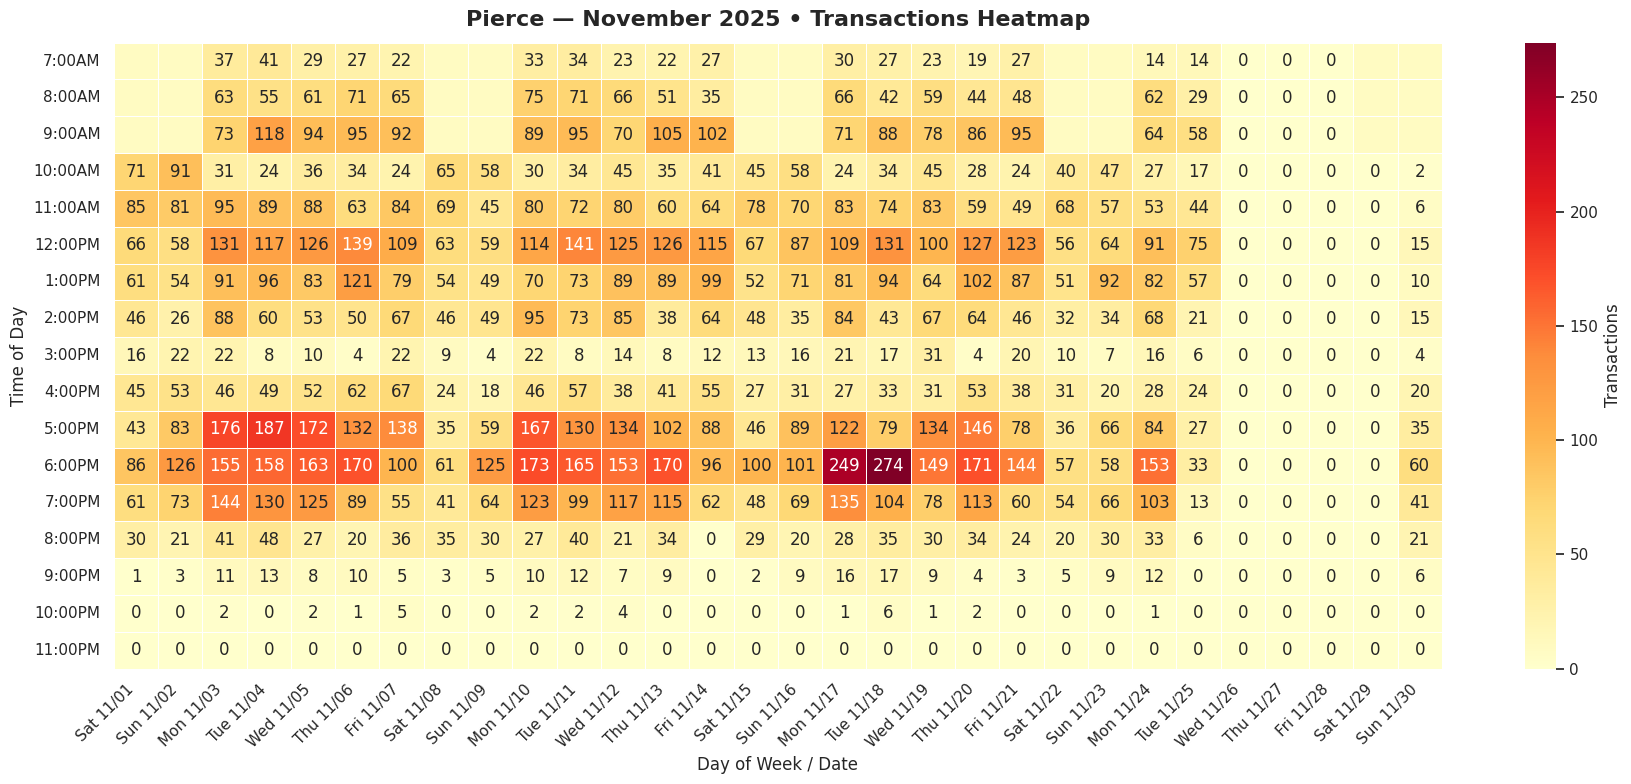

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# ================== CONFIG ==================
path = "/content/Pierce_Nov_2025_tidy.xlsx"
title = "Pierce — November 2025 • Transactions Heatmap"

TIME_ORDER = [
    "7:00AM","8:00AM","9:00AM","10:00AM","11:00AM",
    "12:00PM","1:00PM","2:00PM","3:00PM","4:00PM",
    "5:00PM","6:00PM","7:00PM","8:00PM","9:00PM","10:00PM","11:00PM"
]

# ================== LOAD + CLEAN ==================
df = pd.read_excel(path)
df.columns = df.columns.str.strip()

if "Count" in df.columns and "Transactions" not in df.columns:
    df = df.rename(columns={"Count": "Transactions"})

for c in ["Weekday", "Date", "Time"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

df["Date_dt"] = pd.to_datetime(df["Date"], errors="coerce")
df.loc[df["Date_dt"].isna(), "Date_dt"] = pd.to_datetime(
    df.loc[df["Date_dt"].isna(), "Date"] + "/2025",
    errors="coerce"
)

df["Transactions"] = pd.to_numeric(df["Transactions"], errors="coerce")
df["DayLabel"] = df["Date_dt"].dt.strftime("%a %m/%d")

# ================== FULL GRID ==================
all_dates = pd.date_range(df["Date_dt"].min(), df["Date_dt"].max(), freq="D")
all_labels = all_dates.strftime("%a %m/%d")

pivot = df.pivot_table(
    index="Time",
    columns="DayLabel",
    values="Transactions",
    aggfunc="sum"
)

pivot = pivot.reindex(index=TIME_ORDER, columns=all_labels)

# ================== COLORMAP (NaNs = light yellow) ==================
cmap = mpl.cm.get_cmap("YlOrRd").copy()

# pick the *lightest* yellow from the palette
light_yellow = cmap(0.03)
cmap.set_bad(light_yellow)

# annotations: number only if value exists
annot = pivot.applymap(lambda x: "" if pd.isna(x) else f"{int(x)}")

# ================== PLOT ==================
plt.figure(figsize=(18, 8))
ax = sns.heatmap(
    pivot,
    cmap=cmap,
    vmin=0,
    linewidths=0.5,
    linecolor="white",
    annot=annot,
    fmt="",
    cbar_kws={"label": "Transactions"},
    mask=np.zeros_like(pivot, dtype=bool)  # draw NaNs
)

ax.set_title(title, fontsize=16, weight="bold", pad=12)
ax.set_xlabel("Day of Week / Date")
ax.set_ylabel("Time of Day")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()


# another location

In [ ]:
import re
import pandas as pd
import numpy as np
from openpyxl import load_workbook

# =========================================================
#  MULTI-SHEET WORKBOOK -> TIDY (Late Night sheet only)
#  Reads sheet: "PIERCE LATE NIGHT"
#  Outputs: LateNight_Pierce_Nov_2025_tidy.xlsx
# =========================================================

# ==================== CONFIG ====================
INPUT_XLSX = "/content/2026 today Daily Transactions November 2025.xlsx"  # <-- your workbook path
SHEET_NAME = "PIERCE LATE NIGHT"  # <-- EXACT sheet tab name

DEFAULT_YEAR = 2025
OUTPUT_TIDY_XLSX = "Pierce_LateNight_Nov_2025_tidy.xlsx"

# If you want to keep only certain times, list them here; else None.
KEEP_TIMES = None
# Example:
# KEEP_TIMES = ["8:00PM","8:15PM","8:30PM","8:45PM","9:00PM","9:15PM","9:30PM","9:45PM",
#               "10:00PM","10:15PM","10:30PM","10:45PM","11:00PM"]

# ==================== REGEX ====================
DOW_PATTERN = r"(MONDAY|TUESDAY|WEDNESDAY|THURSDAY|FRIDAY|SATURDAY|SUNDAY)"
HEADER_RE = re.compile(rf"^\s*{DOW_PATTERN}\s+(\d{{1,2}}/\d{{1,2}})(?:/\d{{2,4}})?\s*$", re.I)
TIME_RE = re.compile(r"^\s*(\d{1,2}):(\d{2})\s*(AM|PM)\s*$", re.I)

# ==================== HELPERS ====================
def normalize_time_str(s: str) -> str:
    s = str(s).strip()
    m = TIME_RE.match(s)
    if not m:
        return s
    hh, mm, ap = int(m.group(1)), m.group(2), m.group(3).upper()
    return f"{hh}:{mm}{ap}"

def try_parse_number(x):
    if x is None:
        return np.nan
    if isinstance(x, (int, float)) and not pd.isna(x):
        return float(x)
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return np.nan
    s = s.replace(",", "")
    try:
        return float(s)
    except:
        return np.nan

def date_from_mmdd(mmdd: str, year: int) -> pd.Timestamp:
    mm, dd = mmdd.split("/")
    return pd.Timestamp(year=year, month=int(mm), day=int(dd))

# ==================== LOAD SHEET ====================
wb = load_workbook(INPUT_XLSX, data_only=True)

if SHEET_NAME not in wb.sheetnames:
    raise ValueError(
        f"Sheet '{SHEET_NAME}' not found. Available sheets: {wb.sheetnames}"
    )

ws = wb[SHEET_NAME]
max_row, max_col = ws.max_row, ws.max_column

# ==================== PARSE GRID ====================
records = []

for r in range(1, max_row + 1):
    for c in range(1, max_col + 1):
        v = ws.cell(r, c).value
        if v is None:
            continue

        text = str(v).strip()
        m = HEADER_RE.match(text)
        if not m:
            continue

        weekday = m.group(1).upper()
        mmdd = m.group(2)
        dt = date_from_mmdd(mmdd, DEFAULT_YEAR)

        # Skip CLOSED blocks if "CLOSED" appears near header
        closed_flag = False
        for cc in range(c, min(c + 4, max_col) + 1):
            vv = ws.cell(r, cc).value
            if vv and str(vv).strip().upper() == "CLOSED":
                closed_flag = True
                break
        if closed_flag:
            continue

        # Walk down, collect time/value rows until Total
        rr = r + 1
        blank_streak = 0

        while rr <= max_row:
            cell_val = ws.cell(rr, c).value

            if cell_val is None or str(cell_val).strip() == "":
                blank_streak += 1
                if blank_streak >= 10:
                    break
                rr += 1
                continue

            blank_streak = 0
            label = str(cell_val).strip()

            # Ignore label row like "Late Night"
            if label.upper() == "LATE NIGHT":
                rr += 1
                continue

            # Stop at totals
            if label.upper().startswith("TOTAL"):
                break

            # Capture time rows
            if TIME_RE.match(label):
                tnorm = normalize_time_str(label)
                val = ws.cell(rr, c + 1).value
                num = try_parse_number(val)

                # IMPORTANT: blanks -> 0 (keeps your heatmap consistent)
                num = 0.0 if pd.isna(num) else float(num)

                records.append({
                    "Weekday": weekday.title(),
                    "Date": dt.date().isoformat(),
                    "Time": tnorm,
                    "Transactions": num
                })

            rr += 1

df = pd.DataFrame(records)
if df.empty:
    raise RuntimeError(
        "No day blocks detected on 'PIERCE LATE NIGHT'. "
        "Check that headers look like 'MONDAY 11/3' etc."
    )

# ==================== CLEAN ====================
df["Weekday"] = df["Weekday"].astype(str).str.strip()
df["Date"] = df["Date"].astype(str).str.strip()
df["Time"] = df["Time"].astype(str).str.strip().map(normalize_time_str)
df["Transactions"] = pd.to_numeric(df["Transactions"], errors="coerce").fillna(0)

# Optional keep-times filter
if KEEP_TIMES is not None:
    keep_set = {normalize_time_str(x) for x in KEEP_TIMES}
    df = df[df["Time"].isin(keep_set)].copy()

# ==================== SAVE ====================
with pd.ExcelWriter(OUTPUT_TIDY_XLSX, engine="openpyxl") as writer:
    df.to_excel(writer, index=False, sheet_name="tidy")

print(f"✅ Saved tidy data to: {OUTPUT_TIDY_XLSX}")
print("Rows:", len(df))
print(df.head(12))


✅ Saved tidy data to: Pierce_LateNight_Nov_2025_tidy.xlsx
Rows: 350
     Weekday        Date     Time  Transactions
0   Saturday  2025-11-01   8:00PM           6.0
1   Saturday  2025-11-01   8:15PM          12.0
2   Saturday  2025-11-01   8:30PM           7.0
3   Saturday  2025-11-01   8:45PM           5.0
4   Saturday  2025-11-01   9:00PM           0.0
5   Saturday  2025-11-01   9:15PM           1.0
6   Saturday  2025-11-01   9:30PM           0.0
7   Saturday  2025-11-01   9:45PM           0.0
8   Saturday  2025-11-01  10:00PM           0.0
9     Sunday  2025-11-02   8:00PM           7.0
10    Sunday  2025-11-02   8:15PM           7.0
11    Sunday  2025-11-02   8:30PM           3.0


/tmp/ipython-input-412639356.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("YlOrRd").copy()
/tmp/ipython-input-412639356.py:63: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = pivot.applymap(lambda x: "" if pd.isna(x) else f"{int(x)}")


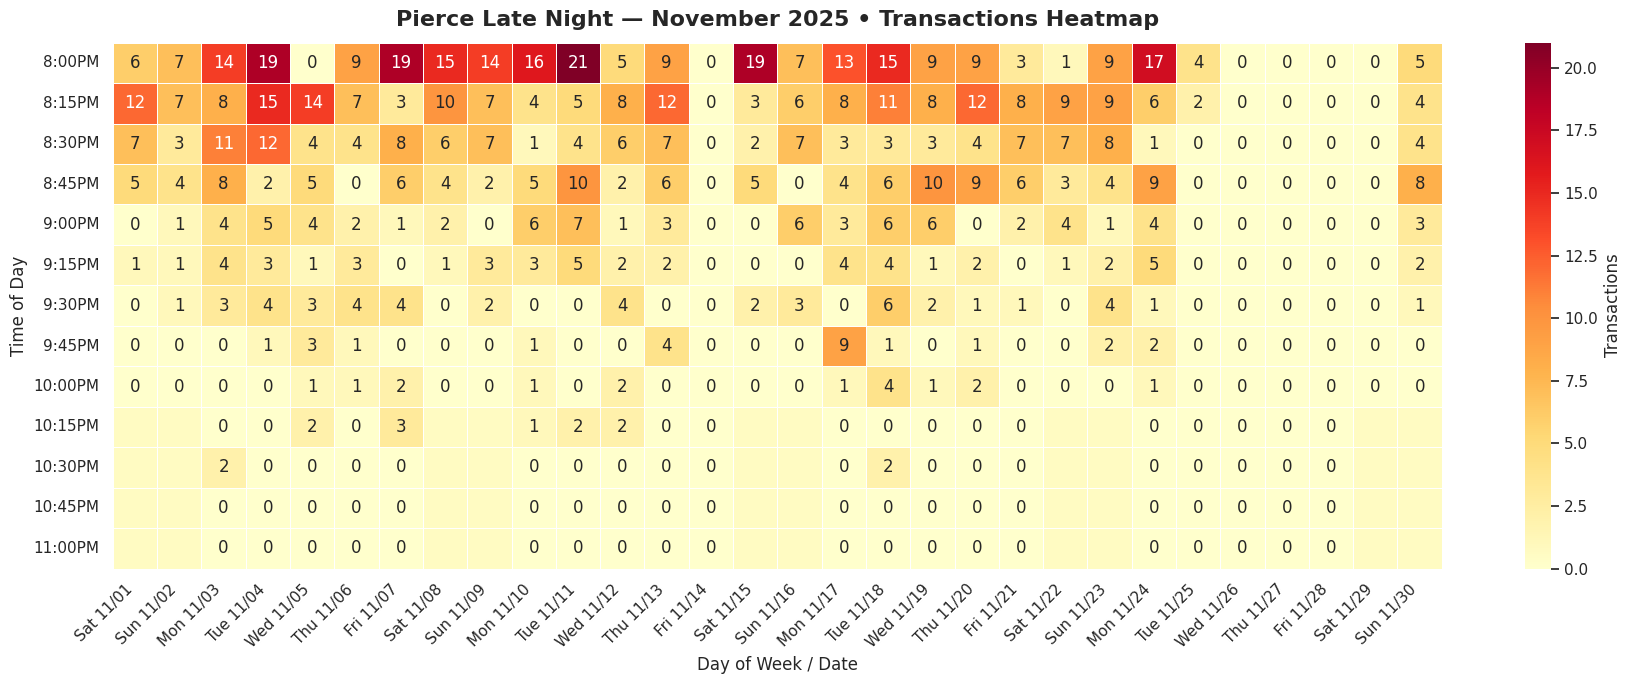

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# ================== CONFIG ==================
path = "/content/Pierce_LateNight_Nov_2025_tidy.xlsx"   # <-- tidy output from the Late Night extractor
title = "Pierce Late Night — November 2025 • Transactions Heatmap"

# Exact late-night time bins (edit if your sheet has more/less)
TIME_ORDER = [
    "8:00PM","8:15PM","8:30PM","8:45PM",
    "9:00PM","9:15PM","9:30PM","9:45PM",
    "10:00PM","10:15PM","10:30PM","10:45PM",
    "11:00PM"
]

# ================== LOAD + CLEAN ==================
df = pd.read_excel(path)
df.columns = df.columns.str.strip()

# Rename if needed
if "Count" in df.columns and "Transactions" not in df.columns:
    df = df.rename(columns={"Count": "Transactions"})

for c in ["Weekday", "Date", "Time"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

df["Date_dt"] = pd.to_datetime(df["Date"], errors="coerce")

# If Date is mm/dd, force year
mask_bad = df["Date_dt"].isna()
if mask_bad.any():
    df.loc[mask_bad, "Date_dt"] = pd.to_datetime(df.loc[mask_bad, "Date"] + "/2025", errors="coerce")

df["Transactions"] = pd.to_numeric(df["Transactions"], errors="coerce")

# Label like "Sat 11/01"
df["DayLabel"] = df["Date_dt"].dt.strftime("%a %m/%d")

# ================== FULL GRID (ALL DAYS IN MONTH) ==================
all_dates = pd.date_range(df["Date_dt"].min(), df["Date_dt"].max(), freq="D")
all_labels = all_dates.strftime("%a %m/%d")

pivot = df.pivot_table(
    index="Time",
    columns="DayLabel",
    values="Transactions",
    aggfunc="sum"
)

# Reindex to force consistent time + day order
pivot = pivot.reindex(index=TIME_ORDER, columns=all_labels)

# ================== COLORMAP (NaNs = light yellow) ==================
cmap = mpl.cm.get_cmap("YlOrRd").copy()
light_yellow = cmap(0.03)   # very light yellow from palette
cmap.set_bad(light_yellow)

# Annotate only if cell exists (so missing = blank label)
annot = pivot.applymap(lambda x: "" if pd.isna(x) else f"{int(x)}")

# ================== PLOT ==================
plt.figure(figsize=(18, 7))
ax = sns.heatmap(
    pivot,
    cmap=cmap,
    vmin=0,
    linewidths=0.5,
    linecolor="white",
    annot=annot,
    fmt="",
    cbar_kws={"label": "Transactions"},
    mask=np.zeros_like(pivot, dtype=bool)  # ensures NaNs still draw using cmap.set_bad
)

ax.set_title(title, fontsize=16, weight="bold", pad=12)
ax.set_xlabel("Day of Week / Date")
ax.set_ylabel("Time of Day")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()


/tmp/ipython-input-256002543.py:50: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = pivot.applymap(lambda x: "" if pd.isna(x) else f"{int(x)}")
/tmp/ipython-input-256002543.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("YlOrRd").copy()


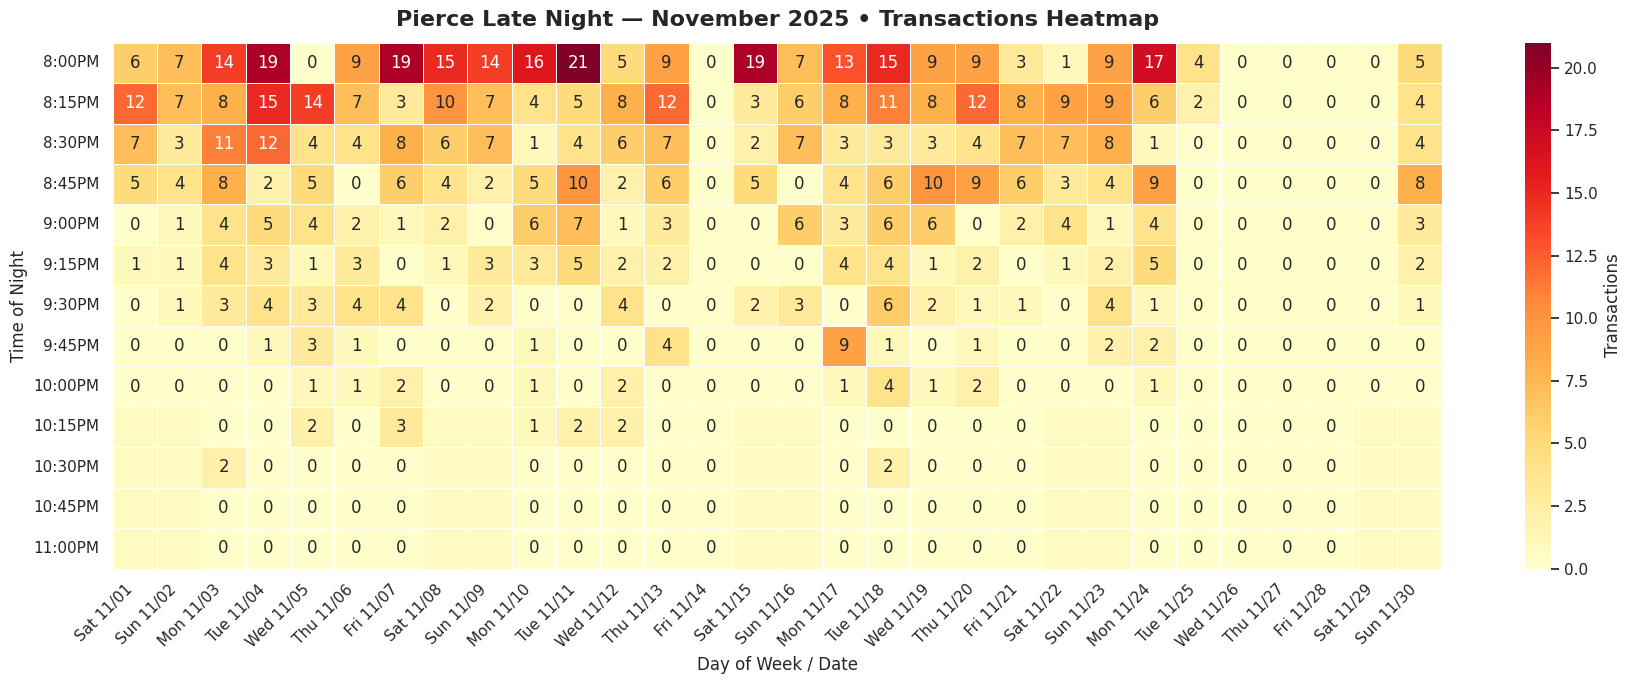

In [ ]:
# other
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# ===================== CONFIG =====================
PATH = "/content/Pierce_LateNight_Nov_2025_tidy.xlsx"
TITLE = "Pierce Late Night — November 2025 • Transactions Heatmap"

# Your full late-night time grid (keep all even if empty)
TIME_ORDER = [
    "8:00PM","8:15PM","8:30PM","8:45PM",
    "9:00PM","9:15PM","9:30PM","9:45PM",
    "10:00PM","10:15PM","10:30PM","10:45PM","11:00PM"
]

# ===================== LOAD =====================
df = pd.read_excel(PATH, sheet_name=0)

# Safety cleaning
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Time"] = df["Time"].astype(str).str.strip()
df["Transactions"] = pd.to_numeric(df["Transactions"], errors="coerce")

# OPTIONAL: If you accidentally saved blanks as 0 but want them blank,
# uncomment this line to convert 0 -> NaN
# df.loc[df["Transactions"] == 0, "Transactions"] = np.nan

# Create x-axis labels like "Sat 11/01"
df["DayLabel"] = df["Date"].dt.strftime("%a %m/%d")

# Create full date span for November based on min/max
all_dates = pd.date_range(df["Date"].min(), df["Date"].max(), freq="D")
all_labels = all_dates.strftime("%a %m/%d")

# ===================== PIVOT =====================
pivot = df.pivot_table(
    index="Time",
    columns="DayLabel",
    values="Transactions",
    aggfunc="sum"
)

# Reindex to enforce full time grid + full date grid
pivot = pivot.reindex(index=TIME_ORDER, columns=all_labels)

# Annotations: show values only where present
annot = pivot.applymap(lambda x: "" if pd.isna(x) else f"{int(x)}")

# ===================== COLORMAP (NaNs = light yellow) =====================
cmap = mpl.cm.get_cmap("YlOrRd").copy()
light_yellow = cmap(0.03)     # near-lightest yellow shade
cmap.set_bad(light_yellow)    # NaNs render as light yellow

# ===================== PLOT =====================
plt.figure(figsize=(18, 7))
ax = sns.heatmap(
    pivot,
    cmap=cmap,
    vmin=0,
    linewidths=0.5,
    linecolor="white",
    annot=annot,
    fmt="",
    cbar_kws={"label": "Transactions"},
    mask=np.zeros_like(pivot, dtype=bool)  # draw NaNs using set_bad()
)

ax.set_title(TITLE, fontsize=16, weight="bold", pad=12)
ax.set_xlabel("Day of Week / Date")
ax.set_ylabel("Time of Night")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()


# Now for other location

/tmp/ipython-input-665486359.py:46: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = pivot.applymap(lambda x: "" if pd.isna(x) else f"{int(x)}")
/tmp/ipython-input-665486359.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("YlOrRd").copy()


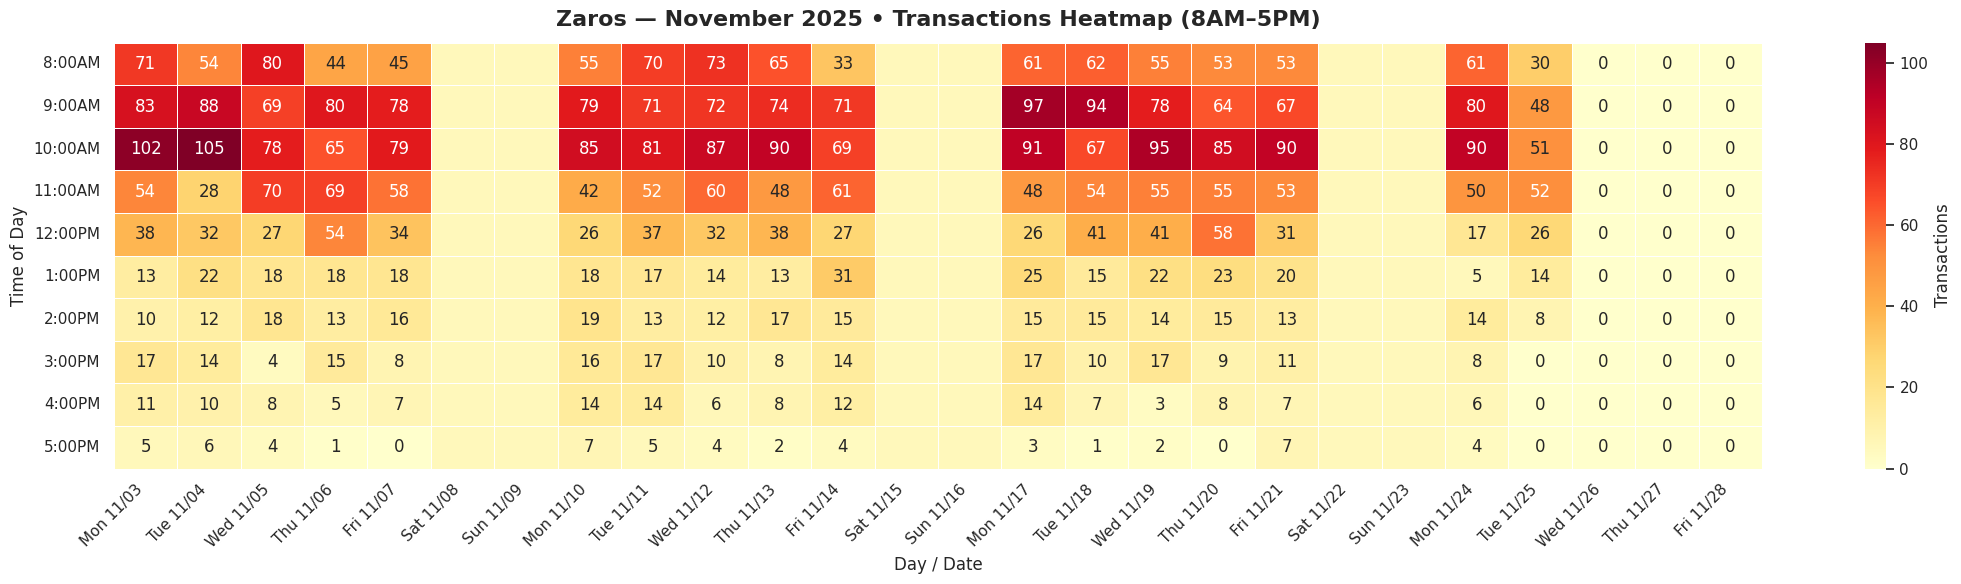

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# ================== CONFIG ==================
PATH = "/content/Zaros_Nov_2025_8am_5pm_tidy.xlsx"
TITLE = "Zaros — November 2025 • Transactions Heatmap (8AM–5PM)"

TIME_ORDER = [
    "8:00AM","9:00AM","10:00AM","11:00AM",
    "12:00PM","1:00PM","2:00PM","3:00PM",
    "4:00PM","5:00PM"
]

# ================== LOAD ==================
df = pd.read_excel(PATH)

df["Date"] = pd.to_datetime(df["Date"])
df["Time"] = df["Time"].astype(str).str.strip()
df["Transactions"] = pd.to_numeric(df["Transactions"], errors="coerce")

# IMPORTANT:
# Empty / closed stays NaN → BLANK on heatmap
df.loc[df["Transactions"] == 0, "Transactions"] = np.nan

df["DayLabel"] = df["Date"].dt.strftime("%a %m/%d")

# Full date range (keeps CLOSED days as blank columns)
all_dates = pd.date_range(df["Date"].min(), df["Date"].max(), freq="D")
all_labels = all_dates.strftime("%a %m/%d")

# ================== PIVOT ==================
pivot = (
    df.pivot_table(
        index="Time",
        columns="DayLabel",
        values="Transactions",
        aggfunc="sum"
    )
    .reindex(index=TIME_ORDER, columns=all_labels)
)

# Annotate ONLY real values
annot = pivot.applymap(lambda x: "" if pd.isna(x) else f"{int(x)}")

# ================== COLORMAP ==================
cmap = mpl.cm.get_cmap("YlOrRd").copy()

# same pale yellow for blanks
light_yellow = cmap(0.05)
cmap.set_bad(light_yellow)

# ================== PLOT ==================
plt.figure(figsize=(22, 6))

ax = sns.heatmap(
    pivot,
    cmap=cmap,
    vmin=0,
    linewidths=0.5,
    linecolor="white",
    annot=annot,
    fmt="",
    cbar_kws={"label": "Transactions"},
    mask=np.zeros_like(pivot, dtype=bool)  # force NaNs to render
)

ax.set_title(TITLE, fontsize=16, weight="bold", pad=12)
ax.set_xlabel("Day / Date")
ax.set_ylabel("Time of Day")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


# another location now AC Create

✅ Saved tidy data to: AC_CREATE_Nov_2025_tidy.xlsx
      Weekday        Date     Time  Transactions
0      Monday  2025-11-03  11:00AM          29.0
1      Monday  2025-11-03  12:00PM          31.0
2      Monday  2025-11-03   1:00PM          18.0
3      Monday  2025-11-03   2:00PM          20.0
4      Monday  2025-11-03   3:00PM          19.0
5      Monday  2025-11-03   4:00PM          11.0
6      Monday  2025-11-03   5:00PM          10.0
28    Tuesday  2025-11-04  11:00AM          35.0
29    Tuesday  2025-11-04  12:00PM          38.0
30    Tuesday  2025-11-04   1:00PM          27.0
31    Tuesday  2025-11-04   2:00PM          13.0
32    Tuesday  2025-11-04   3:00PM          24.0
33    Tuesday  2025-11-04   4:00PM          14.0
34    Tuesday  2025-11-04   5:00PM           5.0
56  Wednesday  2025-11-05  11:00AM          21.0
57  Wednesday  2025-11-05  12:00PM          31.0
58  Wednesday  2025-11-05   1:00PM          24.0
59  Wednesday  2025-11-05   2:00PM          17.0
60  Wednesday  202

/tmp/ipython-input-2892520738.py:259: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


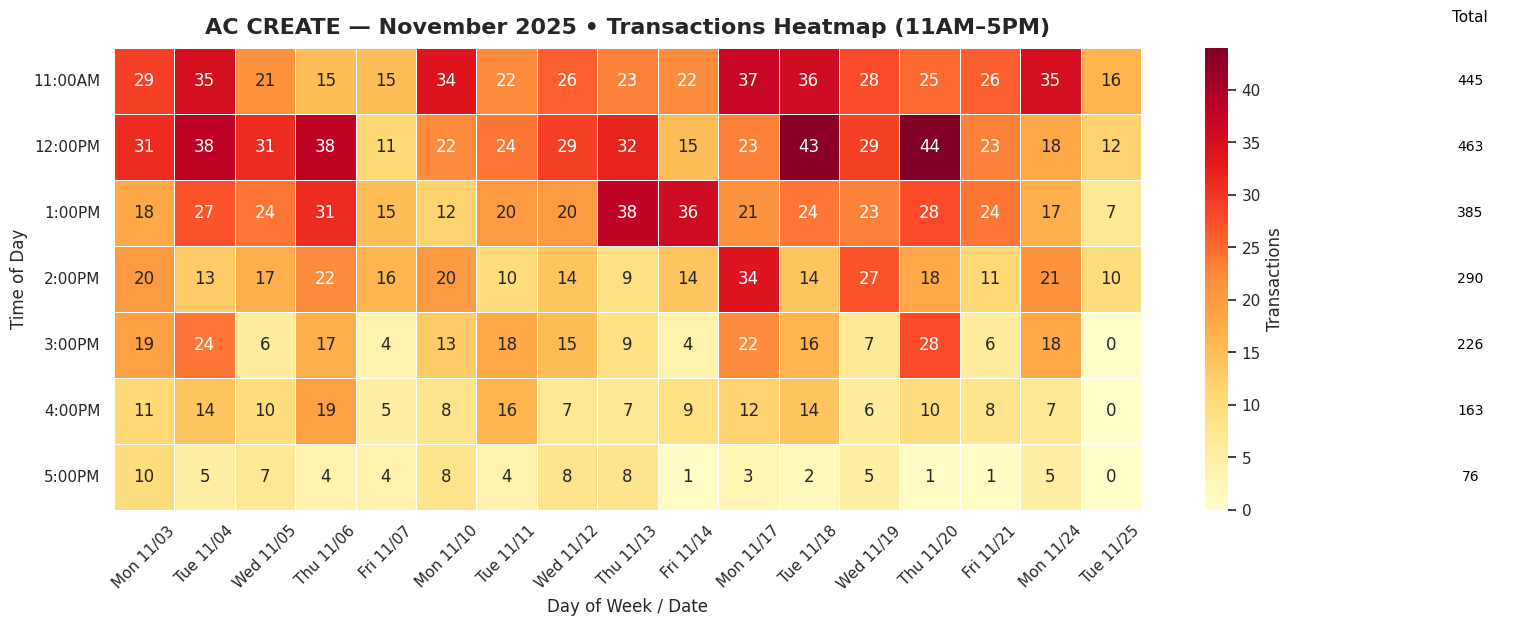

✅ Saved heatmap image to: AC_CREATE_Nov_2025_heatmap.png


In [ ]:
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from openpyxl import load_workbook
from matplotlib.patches import Rectangle

# ==================== CONFIG ====================
INPUT_XLSX = "/content/2026 today Daily Transactions November 2025.xlsx"
SHEET_NAME = "AC - CREATE"   # <-- change if your tab name differs
DEFAULT_YEAR = 2025

TITLE = "AC CREATE — November 2025 • Transactions Heatmap (11AM–5PM)"
OUTPUT_TIDY_XLSX = "AC_CREATE_Nov_2025_tidy.xlsx"
OUTPUT_PNG = "AC_CREATE_Nov_2025_heatmap.png"

KEEP_TIMES = ["11:00AM","12:00PM","1:00PM","2:00PM","3:00PM","4:00PM","5:00PM"]

# Drop all-zero days? (For CREATE you probably want TRUE)
DROP_ALL_ZERO_DAYS = True

# ==================== REGEX ====================
DOW_RE   = re.compile(r"^\s*(MONDAY|TUESDAY|WEDNESDAY|THURSDAY|FRIDAY|SATURDAY|SUNDAY)\b", re.I)
MMDD_RE  = re.compile(r"(\d{1,2}/\d{1,2})(?:/\d{2,4})?")
TIME_RE  = re.compile(r"^\s*(\d{1,2}):(\d{2})\s*(AM|PM)\s*$", re.I)

# ==================== HELPERS ====================
def normalize_time_str(s: str) -> str:
    s = str(s).strip()
    m = TIME_RE.match(s)
    if not m:
        return s
    hh, mm, ap = int(m.group(1)), m.group(2), m.group(3).upper()
    return f"{hh}:{mm}{ap}"

def try_parse_number(x):
    if x is None:
        return np.nan
    if isinstance(x, (int, float)) and not pd.isna(x):
        return float(x)
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return np.nan
    s = s.replace(",", "")
    try:
        return float(s)
    except:
        return np.nan

def date_from_mmdd(mmdd: str, year: int) -> pd.Timestamp:
    mm, dd = mmdd.split("/")
    return pd.Timestamp(year=year, month=int(mm), day=int(dd))

def find_weekday_and_mmdd(ws, r, c, max_col):
    """
    Detect weekday in cell (or merged header), and find mm/dd either:
      - in same cell text, OR
      - within next 1–2 cells to the right (very common).
    """
    v = ws.cell(r, c).value
    if v is None:
        return None

    text = str(v).strip()
    m_dow = DOW_RE.match(text)
    if not m_dow:
        return None

    weekday = m_dow.group(1).upper()

    m_mmdd = MMDD_RE.search(text)
    if m_mmdd:
        return weekday, m_mmdd.group(1)

    for cc in range(c + 1, min(c + 3, max_col + 1)):
        vv = ws.cell(r, cc).value
        if vv is None:
            continue
        s2 = str(vv).strip()
        m2 = MMDD_RE.search(s2)
        if m2:
            return weekday, m2.group(1)

    return None

def time_sort_key(t):
    m = TIME_RE.match(str(t).strip())
    if not m:
        return (99, 99)
    h = int(m.group(1))
    mm = int(m.group(2))
    ap = m.group(3).upper()
    if ap == "AM":
        hh = 0 if h == 12 else h
    else:
        hh = 12 if h == 12 else h + 12
    return (hh, mm)

# ==================== STEP 1: READ GRID -> TIDY ====================
wb = load_workbook(INPUT_XLSX, data_only=True)

if SHEET_NAME not in wb.sheetnames:
    raise ValueError(f"Sheet '{SHEET_NAME}' not found. Available sheets: {wb.sheetnames}")

ws = wb[SHEET_NAME]
max_row, max_col = ws.max_row, ws.max_column

keep_set = {normalize_time_str(t) for t in KEEP_TIMES}
records = []

for r in range(1, max_row + 1):
    for c in range(1, max_col + 1):
        header = find_weekday_and_mmdd(ws, r, c, max_col)
        if not header:
            continue

        weekday, mmdd = header
        dt = date_from_mmdd(mmdd, DEFAULT_YEAR)

        # Skip if "CLOSED" is near header row
        closed_flag = False
        for cc in range(c, min(c + 8, max_col) + 1):
            vv = ws.cell(r, cc).value
            if vv and "CLOSED" in str(vv).strip().upper():
                closed_flag = True
                break
        if closed_flag:
            continue

        # Read down time/value rows
        rr = r + 1
        blank_streak = 0

        while rr <= max_row:
            cell_val = ws.cell(rr, c).value

            if cell_val is None or str(cell_val).strip() == "":
                blank_streak += 1
                if blank_streak >= 8:
                    break
                rr += 1
                continue

            blank_streak = 0
            label = str(cell_val).strip()

            # Stop at Total row
            if label.upper().startswith("TOTAL"):
                break

            # Skip non-time label rows
            if label.upper() in {"LATE NIGHT"}:
                rr += 1
                continue

            if TIME_RE.match(label):
                tnorm = normalize_time_str(label)
                if tnorm in keep_set:
                    val = ws.cell(rr, c + 1).value
                    num = try_parse_number(val)
                    num = 0.0 if pd.isna(num) else float(num)

                    records.append({
                        "Weekday": weekday.title(),
                        "Date": dt.date().isoformat(),
                        "Time": tnorm,
                        "Transactions": num
                    })

            rr += 1

df = pd.DataFrame(records)
if df.empty:
    raise RuntimeError("No day blocks detected. Check the sheet header cells (weekday + mm/dd).")

# De-dupe in case merged headers cause double-detection
df["Date_dt"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Date_dt", "Time"]).drop_duplicates(subset=["Date", "Time"], keep="first").drop(columns=["Date_dt"])

with pd.ExcelWriter(OUTPUT_TIDY_XLSX, engine="openpyxl") as writer:
    df.to_excel(writer, index=False, sheet_name="tidy")

print(f"✅ Saved tidy data to: {OUTPUT_TIDY_XLSX}")
print(df.head(20))

# ==================== STEP 2: PIVOT ====================
df["Date"] = pd.to_datetime(df["Date"])
df["DayLabel"] = df["Date"].dt.strftime("%a %m/%d")  # Mon 11/03

pivot = df.pivot_table(
    index="Time",
    columns="DayLabel",
    values="Transactions",
    aggfunc="sum",
    fill_value=0
)

# Column order by true date
col_order = (
    df[["DayLabel", "Date"]]
    .drop_duplicates()
    .sort_values("Date")["DayLabel"]
    .tolist()
)
pivot = pivot.reindex(columns=col_order)


# Row order (11AM->5PM)
pivot = pivot.loc[sorted(pivot.index, key=time_sort_key)]

# Optionally drop all-zero columns
if DROP_ALL_ZERO_DAYS:
    pivot = pivot.loc[:, (pivot.sum(axis=0) != 0)]

# Row totals for right-side column
row_totals = pivot.sum(axis=1).astype(int)

# ==================== STEP 3: PLOT HEATMAP + WHITE TOTALS ====================
sns.set_theme(style="white")

fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[20, 1.2], wspace=0.05)

ax = fig.add_subplot(gs[0, 0])
ax_tot = fig.add_subplot(gs[0, 1])

sns.heatmap(
    pivot,
    ax=ax,
    cmap="YlOrRd",
    vmin=0,
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt=".0f",
    cbar=True,
    cbar_kws={"label": "Transactions"}
)

ax.set_title(TITLE, fontsize=16, weight="bold", pad=10)
ax.set_xlabel("Day of Week / Date")
ax.set_ylabel("Time of Day")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

# Totals column (white background, black text)
ax_tot.set_xlim(0, 1)
ax_tot.set_ylim(0, len(row_totals))
ax_tot.invert_yaxis()
ax_tot.axis("off")

for i, total in enumerate(row_totals.values):
    ax_tot.add_patch(Rectangle((0, i), 1, 1, facecolor="white", edgecolor="white"))
    ax_tot.text(0.5, i + 0.5, f"{int(total)}", ha="center", va="center", fontsize=10, color="black")

ax_tot.text(0.5, -0.35, "Total", ha="center", va="bottom", fontsize=11, color="black")

plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=200, bbox_inches="tight")
plt.show()

print(f"✅ Saved heatmap image to: {OUTPUT_PNG}")


# OTher locatoino


/tmp/ipython-input-309402073.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("YlOrRd").copy()
/tmp/ipython-input-309402073.py:73: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = pivot.applymap(lambda x: "" if (pd.isna(x) or float(x) == 0.0) else f"{int(x)}")


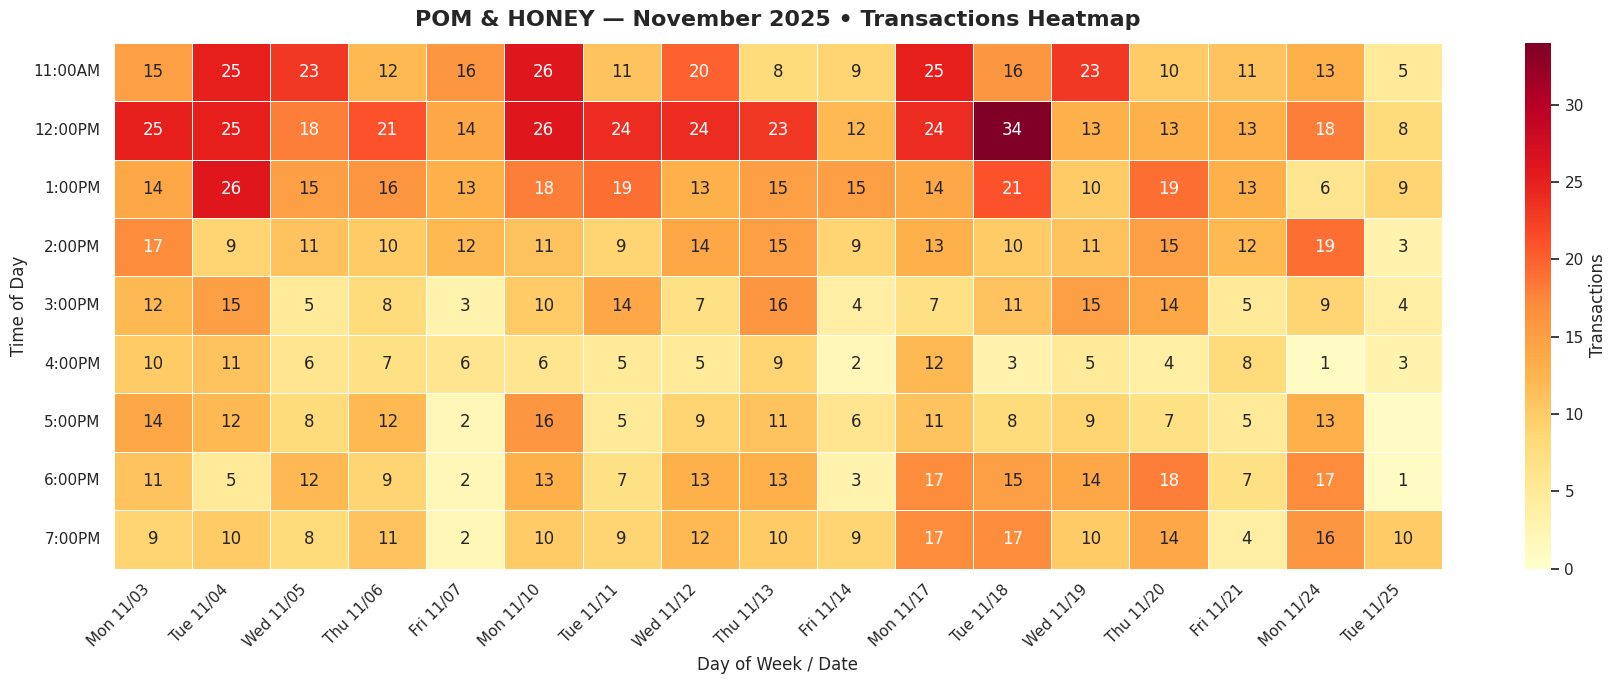

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# ================== CONFIG ==================
path = "/content/ppPom_Honey_Nov_2025_tidy.xlsx"   # <- your uploaded tidy file
title = "POM & HONEY — November 2025 • Transactions Heatmap"

TIME_ORDER = [
    "11:00AM","12:00PM","1:00PM","2:00PM","3:00PM","4:00PM","5:00PM","6:00PM","7:00PM"
]

# If you want CLOSED/blank days to disappear entirely, keep this True:
DROP_ALL_ZERO_DAYS = True

# ================== LOAD + CLEAN ==================
df = pd.read_excel(path)
df.columns = df.columns.str.strip()

# standardize column name
if "Count" in df.columns and "Transactions" not in df.columns:
    df = df.rename(columns={"Count": "Transactions"})

for c in ["Weekday", "Date", "Time"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

df["Date_dt"] = pd.to_datetime(df["Date"], errors="coerce")
df["Transactions"] = pd.to_numeric(df["Transactions"], errors="coerce")

# (important) treat blanks as NaN; but if your tidy has blanks as 0 and you want them blank:
# df.loc[df["Transactions"] == 0, "Transactions"] = np.nan

df["DayLabel"] = df["Date_dt"].dt.strftime("%a %m/%d")

# ================== BUILD PIVOT (KEEP ONLY DAYS THAT EXIST IN TIDY) ==================
pivot = df.pivot_table(
    index="Time",
    columns="DayLabel",
    values="Transactions",
    aggfunc="sum"   # if duplicates, sum them
)

# order rows + columns
day_order = (
    df[["DayLabel", "Date_dt"]]
      .dropna()
      .drop_duplicates()
      .sort_values("Date_dt")["DayLabel"]
      .tolist()
)

pivot = pivot.reindex(index=TIME_ORDER, columns=day_order)

# drop days that are entirely empty (all NaN) or all zeros (if your tidy has zeros)
if DROP_ALL_ZERO_DAYS:
    # keep columns that have at least one non-null AND non-zero value
    keep_cols = []
    for col in pivot.columns:
        s = pivot[col]
        if s.notna().any() and (s.fillna(0).sum() != 0):
            keep_cols.append(col)
    pivot = pivot[keep_cols]

# ================== COLORMAP (NaNs = light yellow) ==================
cmap = mpl.cm.get_cmap("YlOrRd").copy()
light_yellow = cmap(0.03)
cmap.set_bad(light_yellow)

# annotate only if value exists AND value != 0
annot = pivot.applymap(lambda x: "" if (pd.isna(x) or float(x) == 0.0) else f"{int(x)}")

# mask: don't draw cells that are NaN OR zero
mask = pivot.isna() | (pivot.fillna(0) == 0)

# ================== PLOT ==================
plt.figure(figsize=(18, 7))
ax = sns.heatmap(
    pivot,
    cmap=cmap,
    vmin=0,
    linewidths=0.5,
    linecolor="white",
    annot=annot,
    fmt="",
    mask=mask,                     # <- hides empty/0 cells (so they don't plot)
    cbar_kws={"label": "Transactions"}
)

ax.set_title(title, fontsize=16, weight="bold", pad=12)
ax.set_xlabel("Day of Week / Date")
ax.set_ylabel("Time of Day")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()


/tmp/ipython-input-382422845.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("YlOrRd").copy()
/tmp/ipython-input-382422845.py:81: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = pivot.applymap(


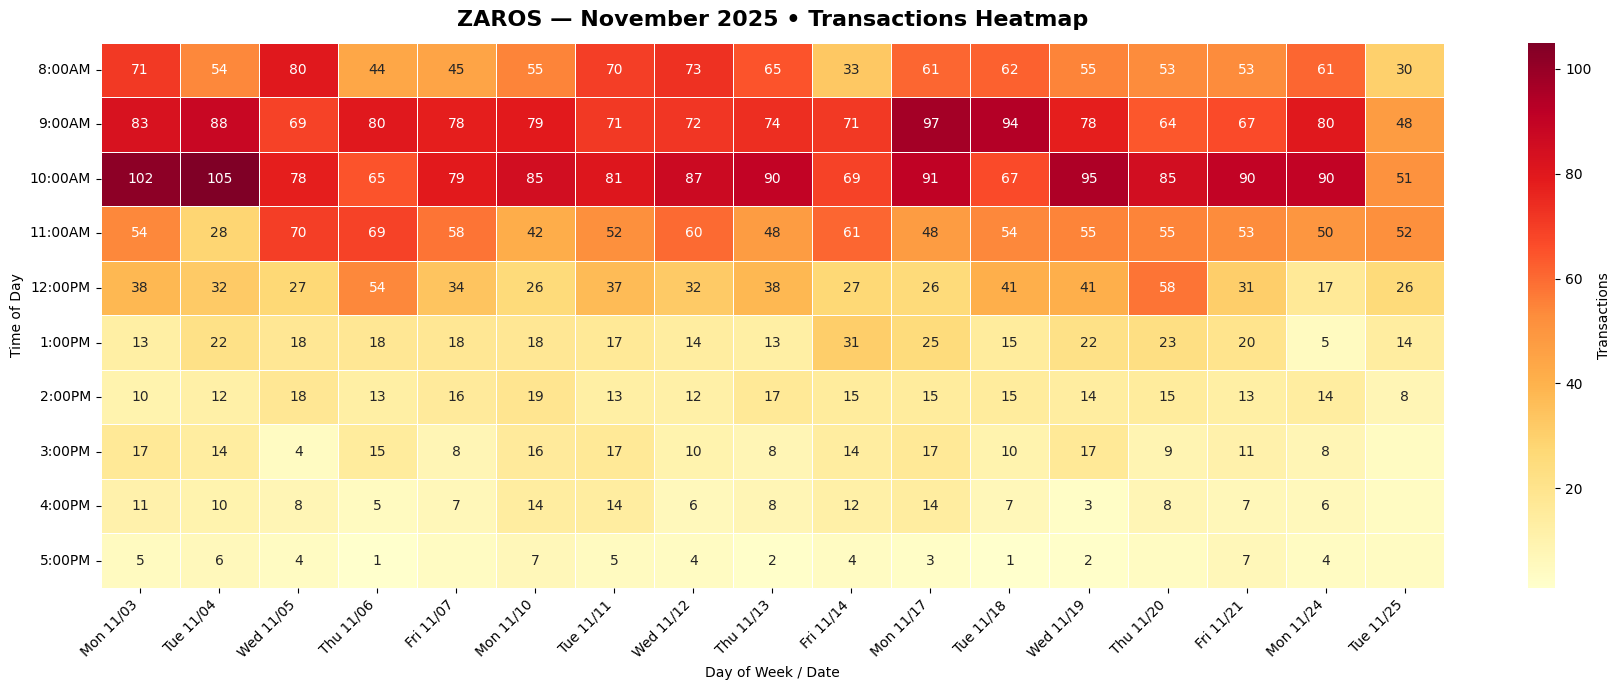

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# ================== CONFIG ==================
path = "/content/Zaros_Nov_2025_8am_5pm_tidy 26.xlsx"

title = "ZAROS — November 2025 • Transactions Heatmap"

TIME_ORDER = [
    "8:00AM","9:00AM","10:00AM","11:00AM",
    "12:00PM","1:00PM","2:00PM","3:00PM",
    "4:00PM","5:00PM"
]

DROP_ALL_ZERO_DAYS = True


# ================== LOAD ==================
df = pd.read_excel(path)
df.columns = df.columns.str.strip()

# rename if needed
if "Count" in df.columns and "Transactions" not in df.columns:
    df = df.rename(columns={"Count": "Transactions"})

# clean
df["Date_dt"] = pd.to_datetime(df["Date"], errors="coerce")
df["Transactions"] = pd.to_numeric(df["Transactions"], errors="coerce")
df["Time"] = df["Time"].astype(str).str.strip()

# label
df["DayLabel"] = df["Date_dt"].dt.strftime("%a %m/%d")


# ================== PIVOT ==================
pivot = df.pivot_table(
    index="Time",
    columns="DayLabel",
    values="Transactions",
    aggfunc="sum"
)

# correct order
day_order = (
    df[["DayLabel", "Date_dt"]]
    .drop_duplicates()
    .sort_values("Date_dt")["DayLabel"]
    .tolist()
)

pivot = pivot.reindex(index=TIME_ORDER, columns=day_order)


# ================== REMOVE CLOSED DAYS ==================
if DROP_ALL_ZERO_DAYS:

    keep_cols = []

    for col in pivot.columns:

        s = pivot[col]

        if s.notna().any() and s.fillna(0).sum() != 0:
            keep_cols.append(col)

    pivot = pivot[keep_cols]


# ================== COLORS ==================
cmap = mpl.cm.get_cmap("YlOrRd").copy()

light_yellow = cmap(0.03)

cmap.set_bad(light_yellow)


# annotate only real values
annot = pivot.applymap(
    lambda x: "" if (pd.isna(x) or x == 0) else f"{int(x)}"
)

mask = pivot.isna() | (pivot == 0)


# ================== PLOT ==================
plt.figure(figsize=(18,7))

ax = sns.heatmap(
    pivot,
    cmap=cmap,
    linewidths=0.5,
    linecolor="white",
    annot=annot,
    fmt="",
    mask=mask,
    cbar_kws={"label": "Transactions"}
)

ax.set_title(title, fontsize=16, weight="bold", pad=12)

ax.set_xlabel("Day of Week / Date")

ax.set_ylabel("Time of Day")

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


plt.tight_layout()

plt.show()

/tmp/ipython-input-2958139780.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("YlOrRd").copy()
/tmp/ipython-input-2958139780.py:63: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = pivot.applymap(


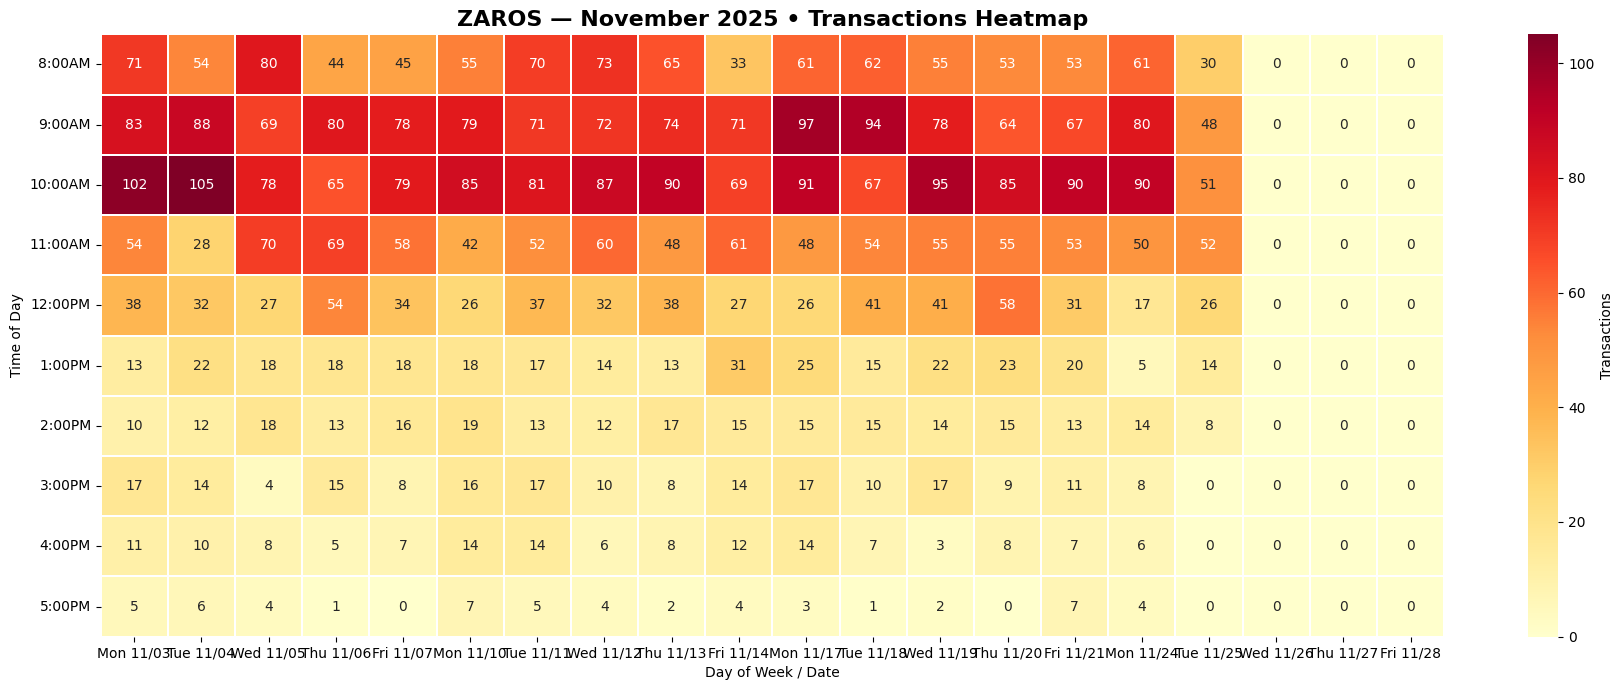

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# ================= CONFIG =================
path = "/content/Zaros_Nov_2025_8am_5pm_tidy 26.xlsx"

title = "ZAROS — November 2025 • Transactions Heatmap"

TIME_ORDER = [
    "8:00AM","9:00AM","10:00AM","11:00AM",
    "12:00PM","1:00PM","2:00PM","3:00PM",
    "4:00PM","5:00PM"
]

# ================= LOAD =================
df = pd.read_excel(path)

df.columns = df.columns.str.strip()

if "Count" in df.columns and "Transactions" not in df.columns:
    df = df.rename(columns={"Count":"Transactions"})

df["Date_dt"] = pd.to_datetime(df["Date"])
df["Transactions"] = pd.to_numeric(df["Transactions"], errors="coerce")
df["Time"] = df["Time"].astype(str).str.strip()

df["DayLabel"] = df["Date_dt"].dt.strftime("%a %m/%d")


# ================= PIVOT =================
pivot = df.pivot_table(

    index="Time",
    columns="DayLabel",
    values="Transactions",
    aggfunc="sum"

)

# FULL DATE RANGE (keeps closed days)
day_order = (
    df[["DayLabel","Date_dt"]]
    .drop_duplicates()
    .sort_values("Date_dt")["DayLabel"]
)

pivot = pivot.reindex(index=TIME_ORDER, columns=day_order)


# ================= COLORS =================

cmap = mpl.cm.get_cmap("YlOrRd").copy()

light_yellow = cmap(0.03)

cmap.set_bad(light_yellow)


# annotate only real values
annot = pivot.applymap(

    lambda x: "" if pd.isna(x) else f"{int(x)}"

)

mask = pivot.isna()


# ================= PLOT =================

plt.figure(figsize=(18,7))

ax = sns.heatmap(

    pivot,

    cmap=cmap,

    linewidths=0.2,

    linecolor="white",

    annot=annot,

    fmt="",

    mask=mask,

    cbar_kws={"label":"Transactions"}

)


# ===== TEXT SETTINGS =====
ax.set_title(title, fontsize=16, weight="bold")
ax.set_xlabel("Day of Week / Date")
ax.set_ylabel("Time of Day")

# MAKE DATES HORIZONTAL (NOT SLANTING)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")

# Optional: Adjust bottom margin if dates get cut off
plt.subplots_adjust(bottom=0.2)

plt.tight_layout()
plt.show()

/tmp/ipython-input-2691165125.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("YlOrRd").copy()
/tmp/ipython-input-2691165125.py:55: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = pivot.applymap(lambda x: "" if pd.isna(x) else f"{int(x)}")


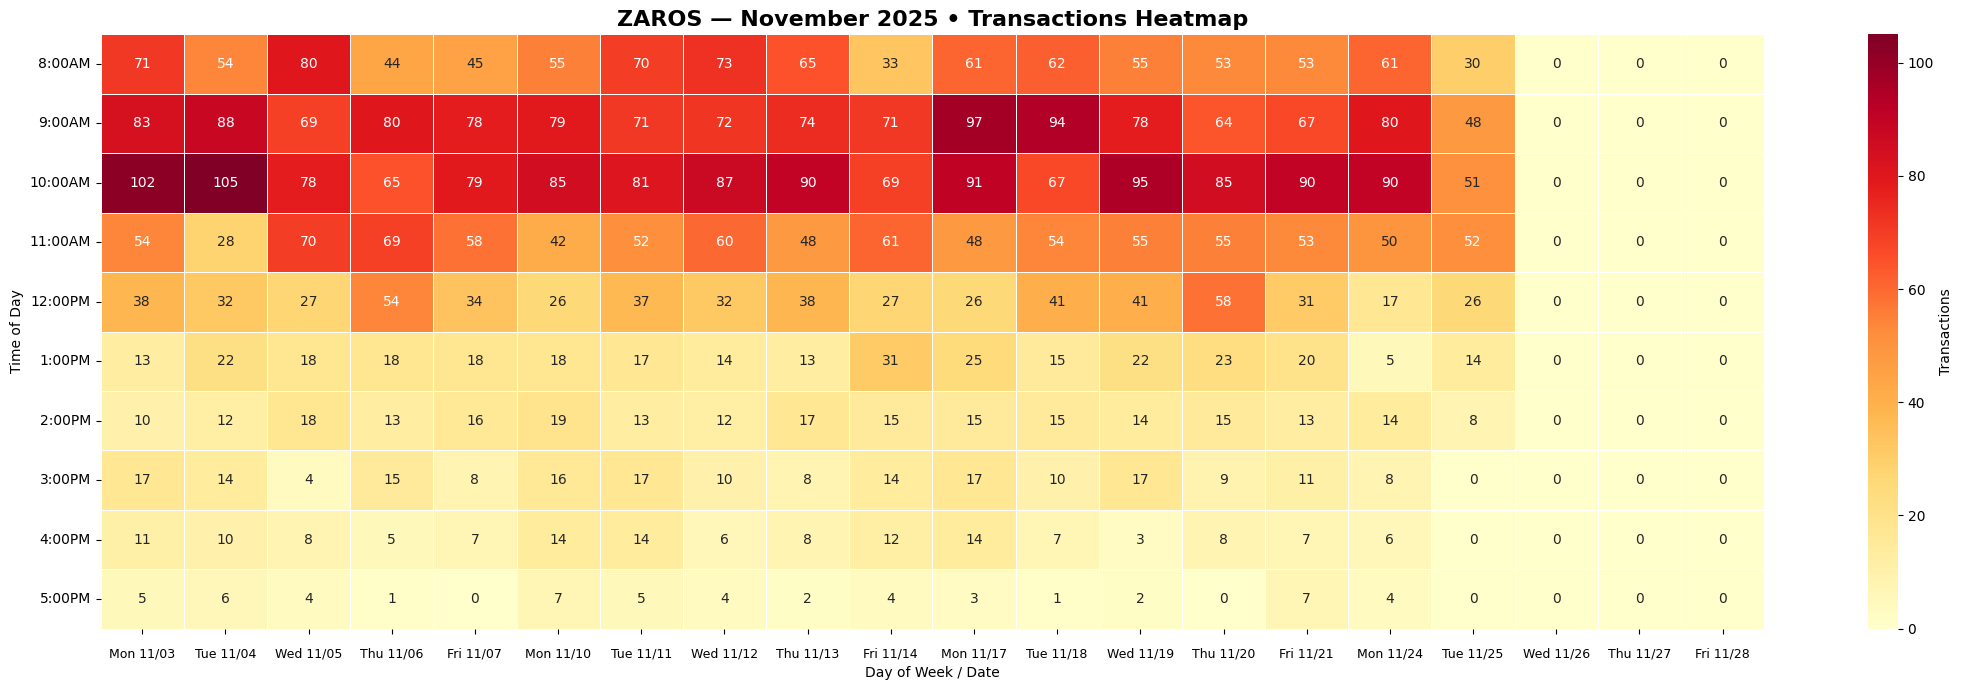

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# ================= CONFIG =================
path = "/content/Zaros_Nov_2025_8am_5pm_tidy 26.xlsx"

title = "ZAROS — November 2025 • Transactions Heatmap"

TIME_ORDER = [
    "8:00AM","9:00AM","10:00AM","11:00AM",
    "12:00PM","1:00PM","2:00PM","3:00PM",
    "4:00PM","5:00PM"
]

# ================= LOAD =================
df = pd.read_excel(path)

df.columns = df.columns.str.strip()

if "Count" in df.columns and "Transactions" not in df.columns:
    df = df.rename(columns={"Count":"Transactions"})

df["Date_dt"] = pd.to_datetime(df["Date"])
df["Transactions"] = pd.to_numeric(df["Transactions"], errors="coerce")
df["Time"] = df["Time"].astype(str).str.strip()

df["DayLabel"] = df["Date_dt"].dt.strftime("%a %m/%d")

# ================= PIVOT =================
pivot = df.pivot_table(
    index="Time",
    columns="DayLabel",
    values="Transactions",
    aggfunc="sum"
)

# FULL DATE RANGE (keeps closed days)
day_order = (
    df[["DayLabel","Date_dt"]]
    .drop_duplicates()
    .sort_values("Date_dt")["DayLabel"]
)

pivot = pivot.reindex(index=TIME_ORDER, columns=day_order)

# ================= COLORS =================
cmap = mpl.cm.get_cmap("YlOrRd").copy()
light_yellow = cmap(0.03)
cmap.set_bad(light_yellow)

# annotate only real values
annot = pivot.applymap(lambda x: "" if pd.isna(x) else f"{int(x)}")
mask = pivot.isna()

# ================= PLOT =================
# INCREASE FIGURE WIDTH FOR MORE SPACING
plt.figure(figsize=(22, 7))  # Increased from 18 to 22

ax = sns.heatmap(
    pivot,
    cmap=cmap,
    linewidths=0.5,
    linecolor="white",
    annot=annot,
    fmt="",
    mask=mask,
    cbar_kws={"label":"Transactions"}
)

# ===== TEXT SETTINGS =====
ax.set_title(title, fontsize=16, weight="bold")
ax.set_xlabel("Day of Week / Date")
ax.set_ylabel("Time of Day")

# MAKE DATES HORIZONTAL
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")

# OPTION 1: Show fewer dates (every other one)
# for i, label in enumerate(ax.xaxis.get_ticklabels()):
#     if i % 2 != 0:  # Show every other label
#         label.set_visible(False)

# OPTION 2: Adjust spacing and font size
plt.setp(ax.xaxis.get_ticklabels(), fontsize=9)  # Smaller font
ax.xaxis.set_tick_params(pad=10)  # More padding between labels and heatmap

# OPTION 3: Rotate slightly if needed (just a tiny bit)
# ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")

plt.tight_layout()
plt.show()

# January 2026

/tmp/ipython-input-729134746.py:53: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = pivot.applymap(lambda x: "" if pd.isna(x) else (str(int(x)) if x > 0 else "–"))


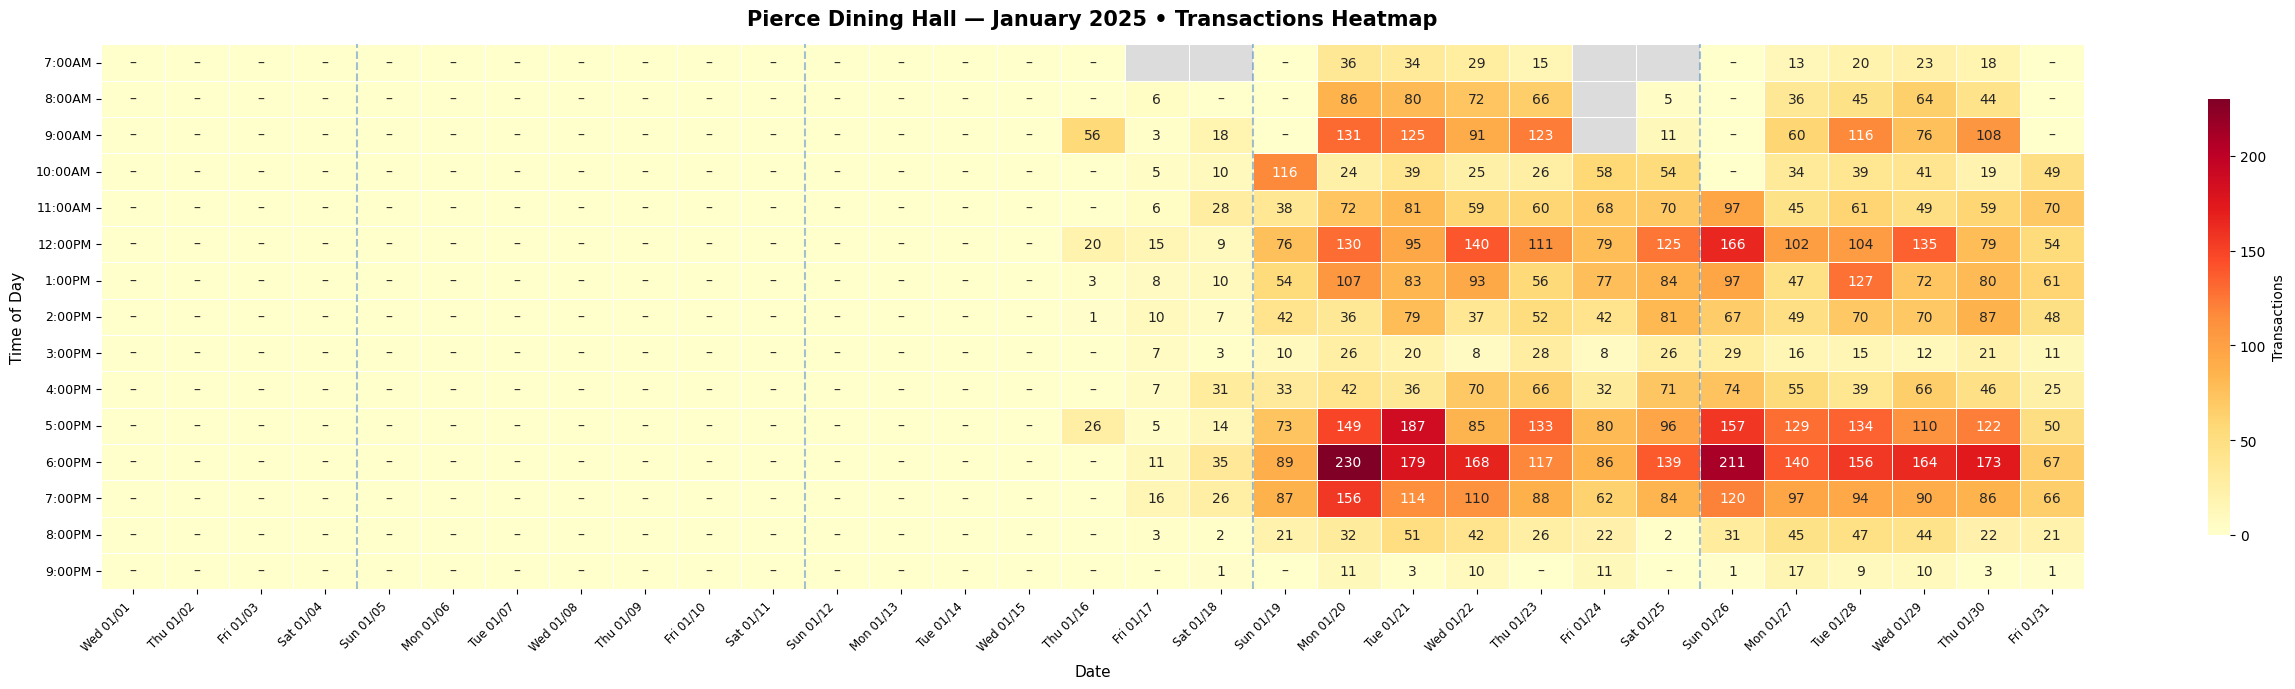

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# ================= CONFIG =================
path = "/content/jan2025_transactions_Pierce Dining Hall .xlsx"
title = "Pierce Dining Hall — January 2025 • Transactions Heatmap"

TIME_ORDER = [
    "7:00AM", "8:00AM", "9:00AM", "10:00AM", "11:00AM",
    "12:00PM", "1:00PM", "2:00PM", "3:00PM", "4:00PM",
    "5:00PM", "6:00PM", "7:00PM", "8:00PM", "9:00PM"
]

# ================= LOAD =================
df = pd.read_excel(path, header=1) # Specify header=1 to use the second row as headers
df.columns = df.columns.str.strip()
df["Date_dt"] = pd.to_datetime(df["Date"])
df["Transactions"] = pd.to_numeric(df["Transactions"], errors="coerce")
df["Time"] = df["Time"].astype(str).str.strip()
df["DayLabel"] = df["Date_dt"].dt.strftime("%a %m/%d")

# Mark closed days as NaN so they render differently
closed_keywords = ["CLOSED", "INTERMISSION"]
if "Notes" in df.columns:
    is_closed = df["Notes"].astype(str).str.upper().str.contains("|".join(closed_keywords), na=False)
    df.loc[is_closed, "Transactions"] = np.nan

# ================= PIVOT =================
pivot = df.pivot_table(
    index="Time",
    columns="DayLabel",
    values="Transactions",
    aggfunc="sum"
)

# Full ordered date range
day_order = (
    df[["DayLabel", "Date_dt"]]
    .drop_duplicates()
    .sort_values("Date_dt")["DayLabel"]
)
pivot = pivot.reindex(index=TIME_ORDER, columns=day_order)

# ================= COLORS =================
cmap = mpl.colormaps["YlOrRd"].copy()
light_yellow = cmap(0.03)
cmap.set_bad("#EBEBEB")  # grey for closed days

# Annotations: blank for NaN, number for real values
annot = pivot.map(lambda x: "" if pd.isna(x) else (str(int(x)) if x > 0 else "–"))
mask = pivot.isna()

# ================= PLOT =================
fig, ax = plt.subplots(figsize=(26, 7))

sns.heatmap(
    pivot,
    ax=ax,
    cmap=cmap,
    linewidths=0.4,
    linecolor="white",
    annot=annot,
    fmt="",
    mask=mask,
    cbar_kws={"label": "Transactions", "shrink": 0.8},
    vmin=0,
)

# Closed day overlay (grey fill, no color scale)
sns.heatmap(
    pivot.isna().astype(float).replace(0, np.nan),
    ax=ax,
    cmap=mpl.colors.ListedColormap(["#DCDCDC"]),
    linewidths=0.4,
    linecolor="white",
    cbar=False,
    mask=~mask,
)

# ================= LABELS =================
ax.set_title(title, fontsize=15, weight="bold", pad=14)
ax.set_xlabel("Date", fontsize=11, labelpad=8)
ax.set_ylabel("Time of Day", fontsize=11, labelpad=8)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8.5)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

# ================= WEEK DIVIDERS =================
# Draw vertical lines between weeks
dates_sorted = df[["DayLabel", "Date_dt"]].drop_duplicates().sort_values("Date_dt").reset_index(drop=True)
for i, row in dates_sorted.iterrows():
    if row["Date_dt"].weekday() == 6 and i > 0:  # Sunday = start of new display week
        ax.axvline(x=i, color="steelblue", linewidth=1.5, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Total days in dataset: 31
Days actually open (with transactions): 16
Closed days (filtered out): 15


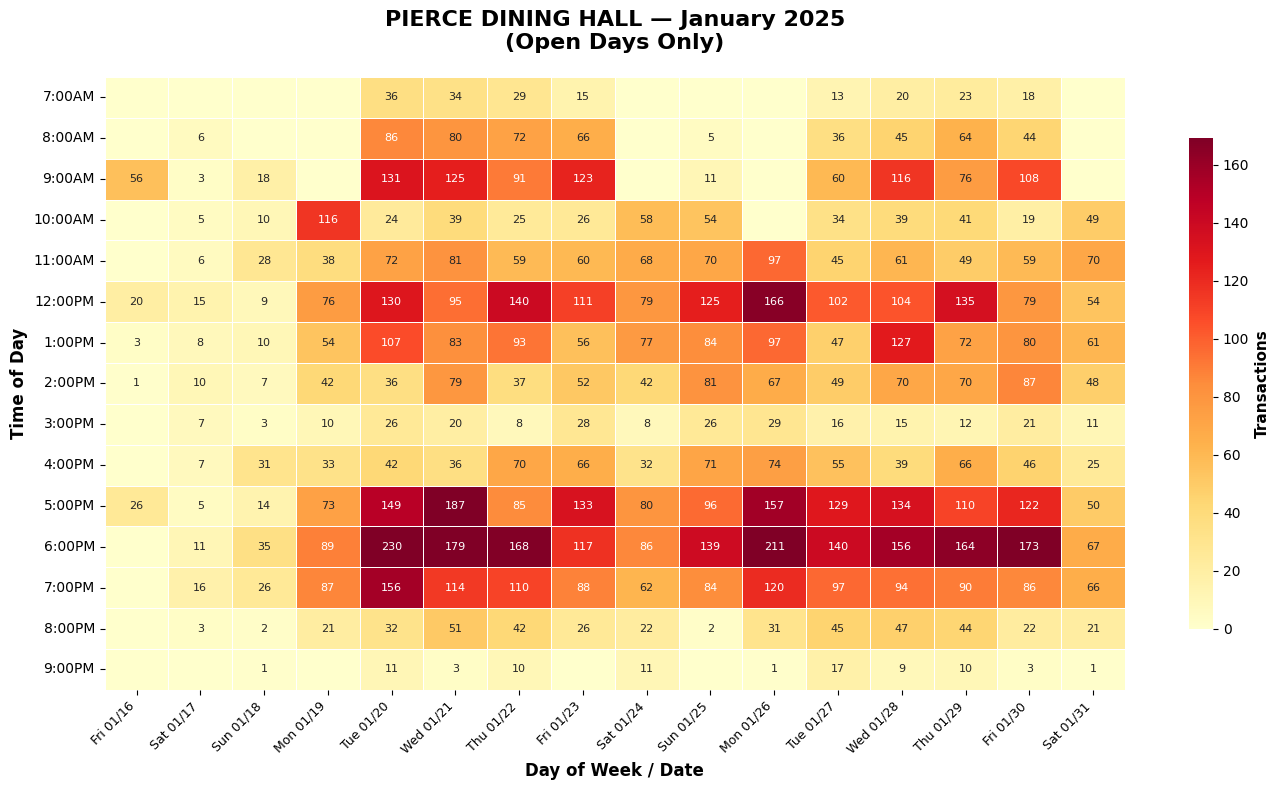


PIERCE DINING HALL - JANUARY 2025 (OPEN DAYS ONLY)
Total transactions: 12,521
Number of open days: 16
Average per open day: 783
Peak day: Tue 01/20 (1,268)
Peak hour: 6:00PM (1,965)

Top 5 Busiest Days:
  Tue 01/20: 1,268
  Wed 01/21: 1,206
  Wed 01/28: 1,076
  Mon 01/26: 1,050
  Thu 01/22: 1,039

Transactions by Hour:
  6:00PM: 1,965
  5:00PM: 1,550
  12:00PM: 1,440
  7:00PM: 1,296
  1:00PM: 1,059
  9:00AM: 918
  11:00AM: 863
  2:00PM: 778
  4:00PM: 693
  10:00AM: 539
  8:00AM: 504
  8:00PM: 411
  3:00PM: 240
  7:00AM: 188
  9:00PM: 77


In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

# ================= LOAD DATA =================
file_path = "/content/jan2025_transactions_Pierce Dining Hall .xlsx"

# Read the Excel file
df = pd.read_excel(file_path, sheet_name=0, skiprows=1, header=None)
df = df.iloc[:, :4]  # keep first 4 columns only
df.columns = ['Weekday', 'Date', 'Time', 'Transactions']
# Remove the row that contains the column names mistakenly read as data
df = df.iloc[1:].copy()

# ================= PROCESS DATA =================
df["Date_dt"] = pd.to_datetime(df["Date"])
df["Transactions"] = pd.to_numeric(df["Transactions"], errors="coerce").fillna(0)
df["Time"] = df["Time"].astype(str).str.strip()

# Use Weekday column from data — strftime is off by one for this dataset
df["DayLabel"] = df["Weekday"].str[:3] + " " + df["Date_dt"].dt.strftime("%m/%d")

# ================= FILTER OUT CLOSED DAYS =================
daily_totals = df.groupby('DayLabel')['Transactions'].sum().reset_index()
daily_totals.columns = ['DayLabel', 'DailyTotal']

open_days = daily_totals[daily_totals['DailyTotal'] > 0]['DayLabel'].tolist()

print(f"Total days in dataset: {len(daily_totals)}")
print(f"Days actually open (with transactions): {len(open_days)}")
print(f"Closed days (filtered out): {len(daily_totals) - len(open_days)}")

df_filtered = df[df['DayLabel'].isin(open_days)].copy()

# ================= PIVOT =================
TIME_ORDER = [
    "7:00AM", "8:00AM", "9:00AM", "10:00AM", "11:00AM",
    "12:00PM", "1:00PM", "2:00PM", "3:00PM", "4:00PM",
    "5:00PM", "6:00PM", "7:00PM", "8:00PM", "9:00PM"
]

pivot = df_filtered.pivot_table(
    index="Time",
    columns="DayLabel",
    values="Transactions",
    aggfunc="sum",
    fill_value=0
)

available_times = [t for t in TIME_ORDER if t in pivot.index]
pivot = pivot.reindex(index=available_times)

day_order = sorted(pivot.columns, key=lambda x: pd.to_datetime(x.split()[1] + '/2025', format='%m/%d/%Y'))
pivot = pivot[day_order]

# ================= COLORS =================
cmap = mpl.colormaps.get_cmap("YlOrRd").copy()
cmap.set_bad('lightgray')

annot = pivot.map(lambda x: f"{int(x)}" if x > 0 else "")

# ================= PLOT =================
fig_width = max(14, len(pivot.columns) * 0.4)
fig_height = max(8, len(pivot.index) * 0.4)

plt.figure(figsize=(fig_width, fig_height))

ax = sns.heatmap(
    pivot,
    cmap=cmap,
    linewidths=0.5,
    linecolor="white",
    annot=annot,
    fmt="",
    cbar_kws={"label": "Transactions", "shrink": 0.8},
    square=False,
    robust=True,
    annot_kws={"size": 8}
)

# ===== TEXT SETTINGS =====
ax.set_title("PIERCE DINING HALL — January 2025\n(Open Days Only)",
             fontsize=16, weight="bold", pad=20)

ax.set_xlabel("Day of Week / Date", fontsize=12, weight="bold")
ax.set_ylabel("Time of Day", fontsize=12, weight="bold")

if len(pivot.columns) > 15:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
else:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center", fontsize=10)

ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)

plt.subplots_adjust(bottom=0.15)

cbar = ax.collections[0].colorbar
cbar.set_label("Transactions", fontsize=11, weight="bold")

plt.tight_layout()
plt.show()

# ===== PRINT SUMMARY =====
print("\n" + "="*60)
print("PIERCE DINING HALL - JANUARY 2025 (OPEN DAYS ONLY)")
print("="*60)
print(f"Total transactions: {pivot.sum().sum():,.0f}")
print(f"Number of open days: {len(pivot.columns)}")
print(f"Average per open day: {pivot.sum().mean():,.0f}")
print(f"Peak day: {pivot.sum().idxmax()} ({pivot.sum().max():,.0f})")
print(f"Peak hour: {pivot.sum(axis=1).idxmax()} ({pivot.sum(axis=1).max():,.0f})")

print("\nTop 5 Busiest Days:")
for day, total in pivot.sum().sort_values(ascending=False).head(5).items():
    print(f"  {day}: {total:,.0f}")

print("\nTransactions by Hour:")
for hour, total in pivot.sum(axis=1).sort_values(ascending=False).items():
    print(f"  {hour}: {total:,.0f}")

/tmp/ipython-input-248140515.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date_dt"] = pd.to_datetime(df["Date"])


DateParseError: Unknown datetime string format, unable to parse: Date, at position 0

/tmp/ipython-input-187669030.py:63: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = pivot.applymap(lambda x: f"{int(x)}" if x > 0 else "")


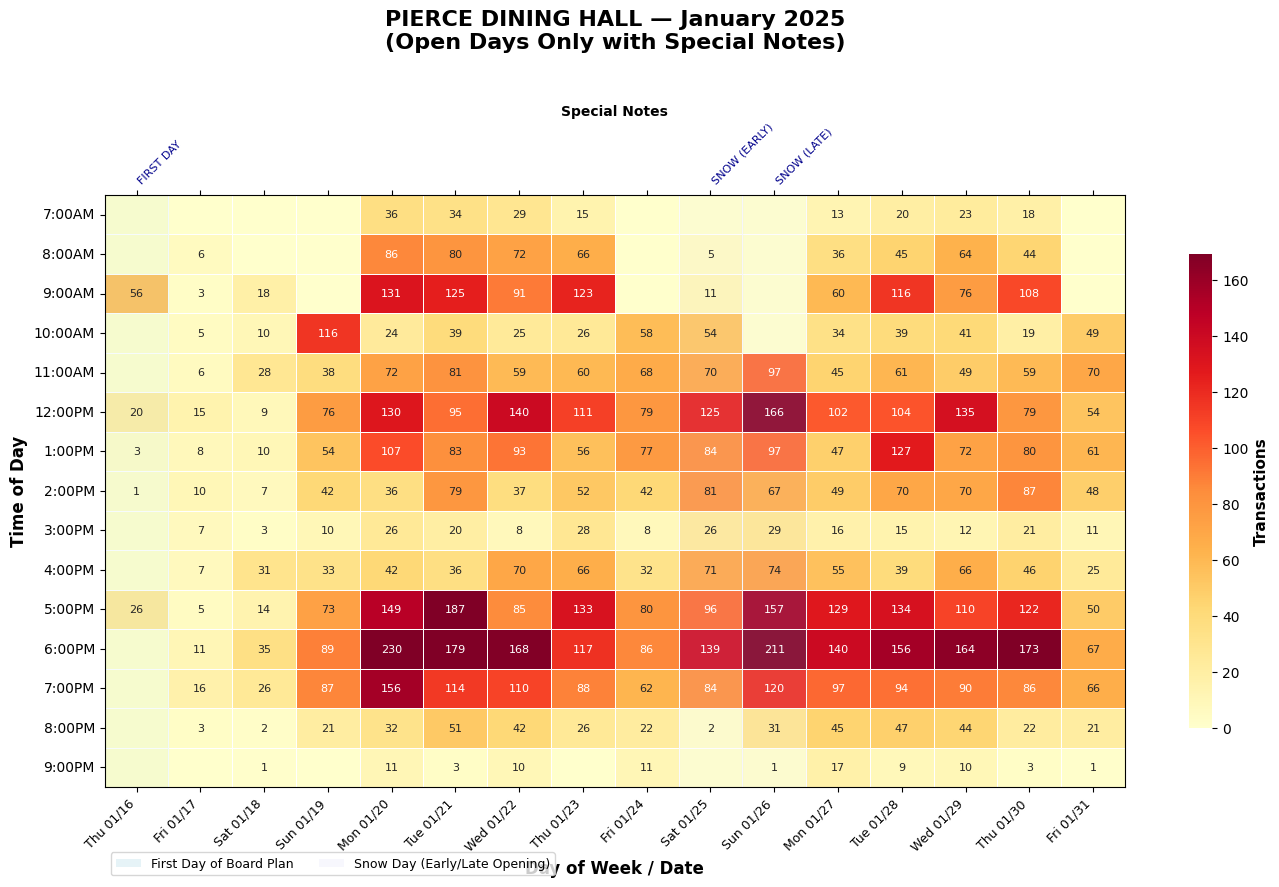


PIERCE DINING HALL - JANUARY 2025 (OPEN DAYS ONLY)
Total transactions: 12,521
Number of open days: 16
Average per open day: 783

Peak day: Mon 01/20 (1,268)
Peak hour: 6:00PM (1,965)

Top 5 Busiest Days:
  Mon 01/20: 1,268
  Tue 01/21: 1,206
  Tue 01/28: 1,076
  Sun 01/26 (SNOW (LATE)): 1,050
  Wed 01/22: 1,039


In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

# ================= LOAD DATA =================
file_path = "/content/jan2025_transactions_Pierce Dining Hall .xlsx"

df = pd.read_excel(file_path, sheet_name=0, skiprows=1)
df.columns = ['Weekday', 'Date', 'Time', 'Transactions']

# ================= PROCESS DATA =================
df["Date_dt"] = pd.to_datetime(df["Date"])
df["Transactions"] = pd.to_numeric(df["Transactions"], errors="coerce").fillna(0)
df["Time"] = df["Time"].astype(str).str.strip()
df["DayLabel"] = df["Date_dt"].dt.strftime("%a %m/%d")

# ================= FILTER OUT CLOSED DAYS =================
daily_totals = df.groupby('DayLabel')['Transactions'].sum().reset_index()
daily_totals.columns = ['DayLabel', 'DailyTotal']
open_days = daily_totals[daily_totals['DailyTotal'] > 0]['DayLabel'].tolist()
df_filtered = df[df['DayLabel'].isin(open_days)].copy()

# ================= ADD NOTES FOR OPEN DAYS =================
day_notes = {}

# First Day of Board Plan (Jan 16)
for day in df_filtered['DayLabel'].unique():
    if day.endswith('/16'):
        day_notes[day] = "FIRST DAY"
    elif day.endswith('/25'):
        day_notes[day] = "SNOW (EARLY)"
    elif day.endswith('/26'):
        day_notes[day] = "SNOW (LATE)"

# ================= PIVOT =================
TIME_ORDER = [
    "7:00AM", "8:00AM", "9:00AM", "10:00AM", "11:00AM",
    "12:00PM", "1:00PM", "2:00PM", "3:00PM", "4:00PM",
    "5:00PM", "6:00PM", "7:00PM", "8:00PM", "9:00PM"
]

pivot = df_filtered.pivot_table(
    index="Time",
    columns="DayLabel",
    values="Transactions",
    aggfunc="sum",
    fill_value=0
)

available_times = [t for t in TIME_ORDER if t in pivot.index]
pivot = pivot.reindex(index=available_times)

day_order = sorted(pivot.columns, key=lambda x: pd.to_datetime(x.split()[1] + '/2025', format='%m/%d/%Y'))
pivot = pivot[day_order]

# ================= COLORS =================
cmap = mpl.colormaps.get_cmap("YlOrRd").copy()
cmap.set_bad('lightgray')

annot = pivot.applymap(lambda x: f"{int(x)}" if x > 0 else "")

# ================= PLOT =================
fig_width = max(14, len(pivot.columns) * 0.4)
plt.figure(figsize=(fig_width, 9))

ax = sns.heatmap(
    pivot,
    cmap=cmap,
    linewidths=0.5,
    linecolor="white",
    annot=annot,
    fmt="",
    cbar_kws={"label": "Transactions", "shrink": 0.8},
    square=False,
    robust=True,
    annot_kws={"size": 8}
)

# ===== ADD NOTES AT TOP =====
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(ax.get_xticks())
ax2.set_xticklabels([day_notes.get(col, '') for col in pivot.columns],
                    rotation=45, ha='left', fontsize=8, color='darkblue')
ax2.xaxis.set_ticks_position('top')
ax2.xaxis.set_label_position('top')
ax2.set_xlabel('Special Notes', fontsize=10, weight='bold')

# ===== HIGHLIGHT SPECIAL DAYS =====
for i, day in enumerate(pivot.columns):
    note = day_notes.get(day, '')
    if 'FIRST DAY' in note:
        ax.add_patch(plt.Rectangle((i, 0), 1, len(pivot.index),
                                   fill=True, alpha=0.1, color='lightblue'))
    elif 'SNOW' in note:
        ax.add_patch(plt.Rectangle((i, 0), 1, len(pivot.index),
                                   fill=True, alpha=0.1, color='lavender'))

# ===== TEXT SETTINGS =====
ax.set_title("PIERCE DINING HALL — January 2025\n(Open Days Only with Special Notes)",
             fontsize=16, weight="bold", pad=40)

ax.set_xlabel("Day of Week / Date", fontsize=12, weight="bold")
ax.set_ylabel("Time of Day", fontsize=12, weight="bold")

if len(pivot.columns) > 15:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
else:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center", fontsize=10)

ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)

plt.subplots_adjust(bottom=0.15, top=0.85)

cbar = ax.collections[0].colorbar
cbar.set_label("Transactions", fontsize=11, weight="bold")

# ===== LEGEND =====
legend_elements = [
    Patch(facecolor='lightblue', alpha=0.3, label='First Day of Board Plan'),
    Patch(facecolor='lavender', alpha=0.3, label='Snow Day (Early/Late Opening)')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, -0.1),
          ncol=2, fontsize=9)

plt.tight_layout()
plt.show()

# ===== PRINT SUMMARY =====
print("\n" + "="*60)
print("PIERCE DINING HALL - JANUARY 2025 (OPEN DAYS ONLY)")
print("="*60)
print(f"Total transactions: {pivot.sum().sum():,.0f}")
print(f"Number of open days: {len(pivot.columns)}")
print(f"Average per open day: {pivot.sum().mean():,.0f}")
print(f"\nPeak day: {pivot.sum().idxmax()} ({pivot.sum().max():,.0f})")
print(f"Peak hour: {pivot.sum(axis=1).idxmax()} ({pivot.sum(axis=1).max():,.0f})")

print("\nTop 5 Busiest Days:")
for day, total in pivot.sum().sort_values(ascending=False).head(5).items():
    note = f" ({day_notes.get(day, '')})" if day_notes.get(day, '') else ""
    print(f"  {day}{note}: {total:,.0f}")

Total days in dataset: 31
Days actually open (with transactions): 16
Closed days (filtered out): 15


/tmp/ipython-input-3185575458.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = pivot.applymap(lambda x: f"{int(x)}" if x > 0 else "")


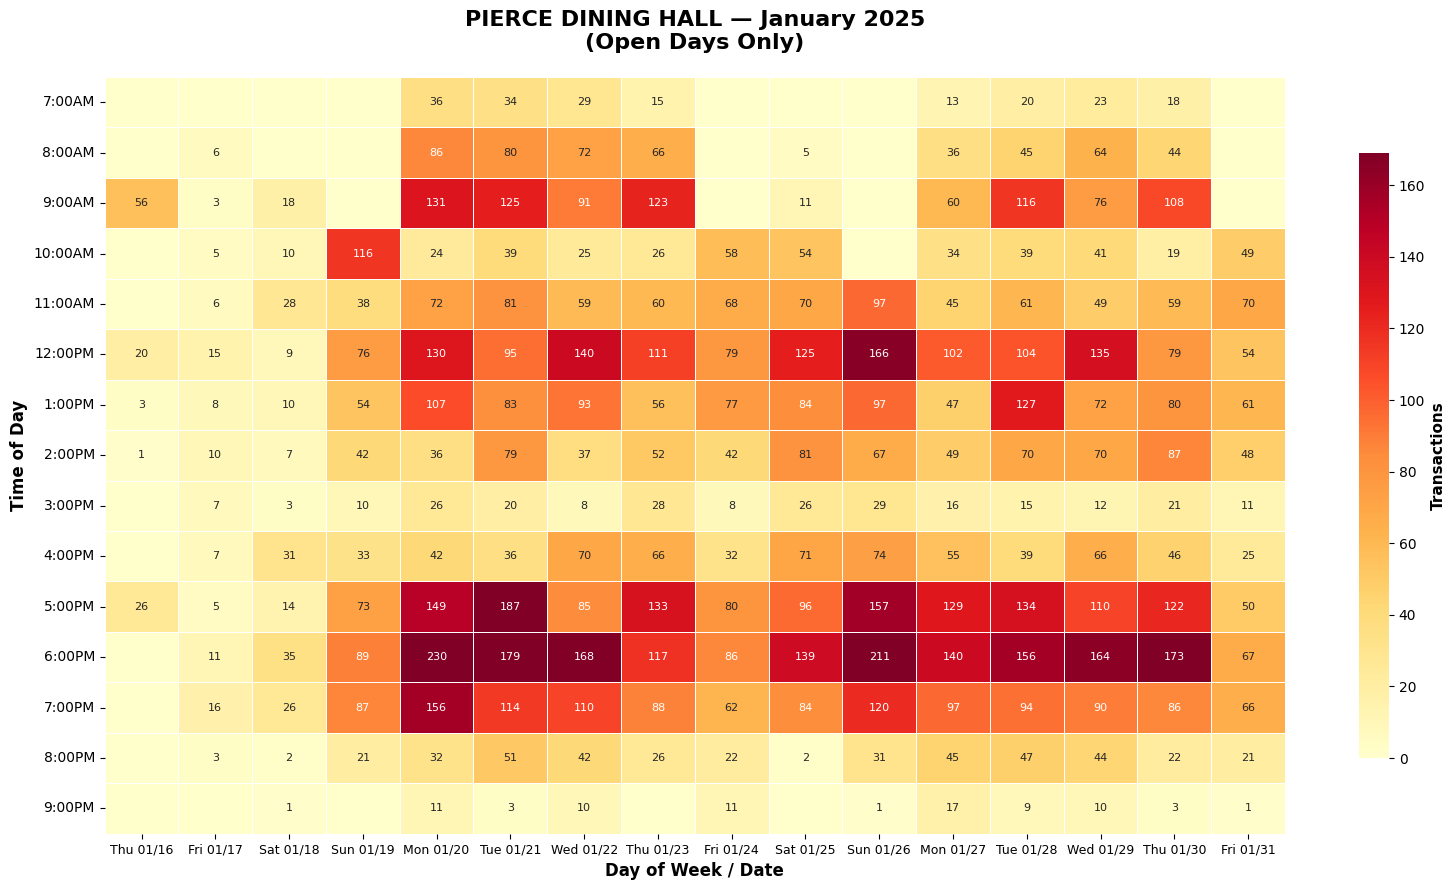


PIERCE DINING HALL - JANUARY 2025 (OPEN DAYS ONLY)
Total transactions: 12,521
Number of open days: 16
Average per open day: 783
Peak day: Mon 01/20 (1,268)
Peak hour: 6:00PM (1,965)

Top 5 Busiest Days:
  Mon 01/20: 1,268
  Tue 01/21: 1,206
  Tue 01/28: 1,076
  Sun 01/26: 1,050
  Wed 01/22: 1,039

Transactions by Hour:
  6:00PM: 1,965
  5:00PM: 1,550
  12:00PM: 1,440
  7:00PM: 1,296
  1:00PM: 1,059
  9:00AM: 918
  11:00AM: 863
  2:00PM: 778
  4:00PM: 693
  10:00AM: 539
  8:00AM: 504
  8:00PM: 411
  3:00PM: 240
  7:00AM: 188
  9:00PM: 77


In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

# ================= LOAD DATA =================
file_path = "/content/jan2025_transactions_Pierce Dining Hall .xlsx"

# Read the Excel file
df = pd.read_excel(file_path, sheet_name=0, skiprows=1)
df.columns = ['Weekday', 'Date', 'Time', 'Transactions']

# ================= PROCESS DATA =================
df["Date_dt"] = pd.to_datetime(df["Date"])
df["Transactions"] = pd.to_numeric(df["Transactions"], errors="coerce").fillna(0)
df["Time"] = df["Time"].astype(str).str.strip()
df["DayLabel"] = df["Date_dt"].dt.strftime("%a %m/%d")

# ================= FILTER OUT CLOSED DAYS =================
# Calculate daily totals
daily_totals = df.groupby('DayLabel')['Transactions'].sum().reset_index()
daily_totals.columns = ['DayLabel', 'DailyTotal']

# Get days that were actually open (daily total > 0)
open_days = daily_totals[daily_totals['DailyTotal'] > 0]['DayLabel'].tolist()

print(f"Total days in dataset: {len(daily_totals)}")
print(f"Days actually open (with transactions): {len(open_days)}")
print(f"Closed days (filtered out): {len(daily_totals) - len(open_days)}")

# Filter dataframe to only include open days
df_filtered = df[df['DayLabel'].isin(open_days)].copy()

# ================= PIVOT =================
TIME_ORDER = [
    "7:00AM", "8:00AM", "9:00AM", "10:00AM", "11:00AM",
    "12:00PM", "1:00PM", "2:00PM", "3:00PM", "4:00PM",
    "5:00PM", "6:00PM", "7:00PM", "8:00PM", "9:00PM"
]

pivot = df_filtered.pivot_table(
    index="Time",
    columns="DayLabel",
    values="Transactions",
    aggfunc="sum",
    fill_value=0
)

# Ensure time order
available_times = [t for t in TIME_ORDER if t in pivot.index]
pivot = pivot.reindex(index=available_times)

# Order columns by date
day_order = sorted(pivot.columns, key=lambda x: pd.to_datetime(x.split()[1] + '/2025', format='%m/%d/%Y'))
pivot = pivot[day_order]

# ================= COLORS =================
cmap = mpl.colormaps.get_cmap("YlOrRd").copy()
cmap.set_bad('lightgray')

# Create annotations (show values as integers)
annot = pivot.applymap(lambda x: f"{int(x)}" if x > 0 else "")

# ================= PLOT =================
# Adjust figure size based on number of columns
fig_width = max(16, len(pivot.columns) * 0.5)  # Increased width for better spacing
fig_height = max(9, len(pivot.index) * 0.45)

plt.figure(figsize=(fig_width, fig_height))

ax = sns.heatmap(
    pivot,
    cmap=cmap,
    linewidths=0.5,
    linecolor="white",
    annot=annot,
    fmt="",
    cbar_kws={"label": "Transactions", "shrink": 0.8},
    square=False,
    robust=True,
    annot_kws={"size": 8}
)

# ===== TEXT SETTINGS - STRAIGHT TEXT =====
ax.set_title("PIERCE DINING HALL — January 2025\n(Open Days Only)",
             fontsize=16, weight="bold", pad=20)

ax.set_xlabel("Day of Week / Date", fontsize=12, weight="bold")
ax.set_ylabel("Time of Day", fontsize=12, weight="bold")

# FORCE STRAIGHT TEXT (NO SLANTING) FOR X-AXIS
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center", fontsize=9)

# Format y-axis labels
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)

# Add more padding at bottom for straight text
plt.subplots_adjust(bottom=0.2)

# Colorbar
cbar = ax.collections[0].colorbar
cbar.set_label("Transactions", fontsize=11, weight="bold")

plt.tight_layout()
plt.show()

# ===== PRINT SUMMARY =====
print("\n" + "="*60)
print("PIERCE DINING HALL - JANUARY 2025 (OPEN DAYS ONLY)")
print("="*60)
print(f"Total transactions: {pivot.sum().sum():,.0f}")
print(f"Number of open days: {len(pivot.columns)}")
print(f"Average per open day: {pivot.sum().mean():,.0f}")
print(f"Peak day: {pivot.sum().idxmax()} ({pivot.sum().max():,.0f})")
print(f"Peak hour: {pivot.sum(axis=1).idxmax()} ({pivot.sum(axis=1).max():,.0f})")

print("\nTop 5 Busiest Days:")
for day, total in pivot.sum().sort_values(ascending=False).head(5).items():
    print(f"  {day}: {total:,.0f}")

print("\nTransactions by Hour:")
for hour, total in pivot.sum(axis=1).sort_values(ascending=False).items():
    print(f"  {hour}: {total:,.0f}")

# Pierce DIning HAll LAte NIght

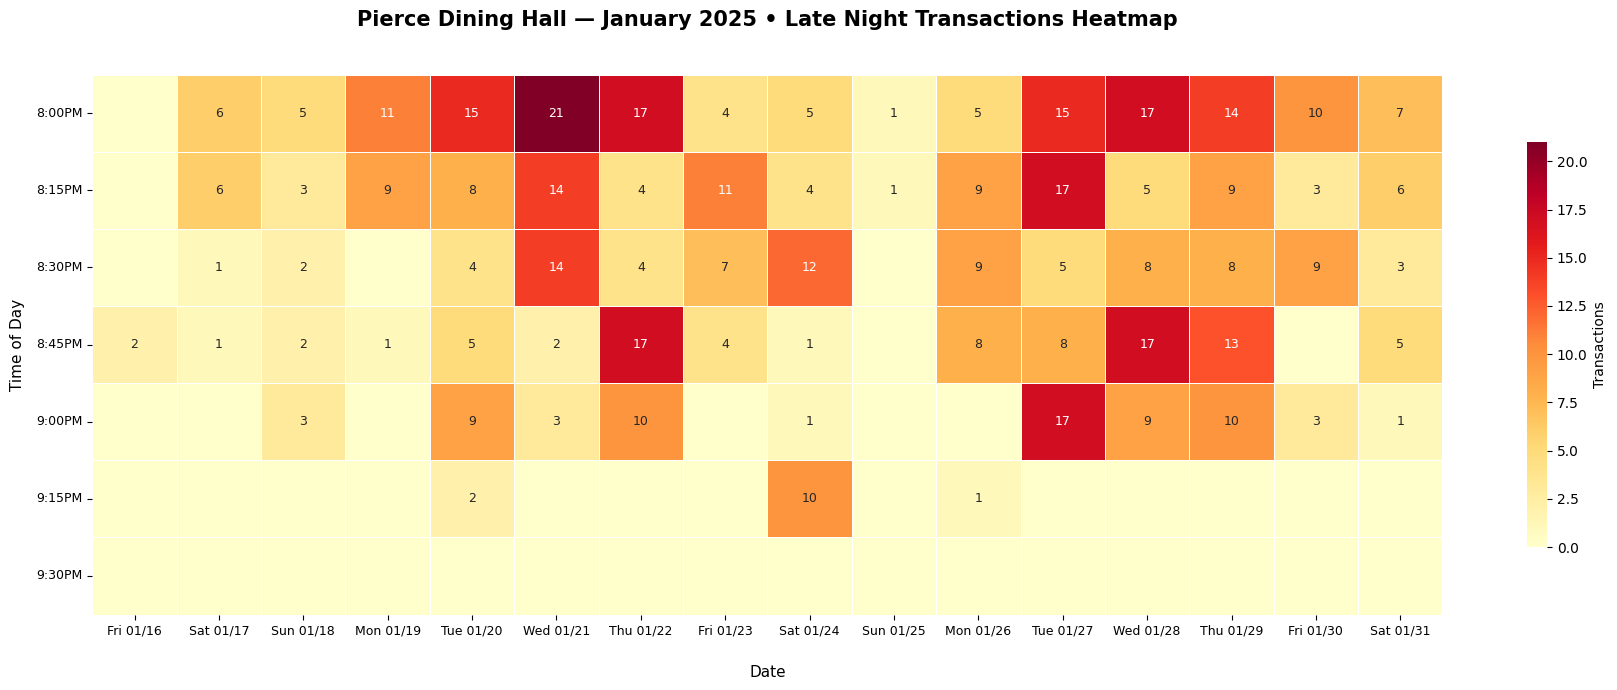

Saved: heatmap_pierce_latenight_jan2025.png


In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# ================= CONFIG =================
path = "jan2025_latenight_transactions.xlsx"
title = "Pierce Dining Hall — January 2025 • Late Night Transactions Heatmap"

TIME_ORDER = [
    "8:00PM", "8:15PM", "8:30PM", "8:45PM",
    "9:00PM", "9:15PM", "9:30PM"
]

# ================= LOAD =================
df = pd.read_excel(path, skiprows=1, header=None)
df.columns = ['Weekday', 'Date', 'Time', 'Transactions', 'Notes']
df["Date_dt"] = pd.to_datetime(df["Date"])
df["Transactions"] = pd.to_numeric(df["Transactions"], errors="coerce")
df["Time"] = df["Time"].astype(str).str.strip()
df["Notes"] = df["Notes"].astype(str).str.strip().replace("nan", "")

# Use Weekday column from data — strftime is off by one for this dataset
df["DayLabel"] = df["Weekday"].str[:3] + " " + df["Date_dt"].dt.strftime("%m/%d")

# ================= FILTER: open days only =================
daily_totals = df.groupby("DayLabel")["Transactions"].sum()
open_days = daily_totals[daily_totals > 0].index.tolist()
df = df[df["DayLabel"].isin(open_days)]

# ================= PIVOT =================
pivot = df.pivot_table(
    index="Time",
    columns="DayLabel",
    values="Transactions",
    aggfunc="sum",
    fill_value=0
)

day_order = sorted(pivot.columns,
                   key=lambda x: pd.to_datetime(x.split()[1] + "/2025", format="%m/%d/%Y"))
pivot = pivot.reindex(index=TIME_ORDER, columns=day_order)

# ================= COLORS =================
cmap = mpl.colormaps["YlOrRd"].copy()
cmap.set_bad("#E0E0E0")

annot = pivot.map(lambda x: "" if pd.isna(x) or x == 0 else str(int(x)))

# ================= PLOT =================
num_days = len(day_order)
fig_width  = max(18, num_days * 0.9)
fig_height = 7

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

sns.heatmap(
    pivot,
    ax=ax,
    cmap=cmap,
    linewidths=0.4,
    linecolor="white",
    annot=annot,
    fmt="",
    cbar_kws={"label": "Transactions", "shrink": 0.75},
    vmin=0,
    vmax=pivot.max().max() if not pivot.empty else 1,
    annot_kws={"size": 9},
)

# ================= LABELS =================
ax.set_title(title, fontsize=15, weight="bold", pad=35)
ax.set_xlabel("Date", fontsize=11, labelpad=20)
ax.set_ylabel("Time of Day", fontsize=11, labelpad=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.subplots_adjust(bottom=0.3)
plt.tight_layout()
plt.savefig("heatmap_pierce_latenight_jan2025.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: heatmap_pierce_latenight_jan2025.png")

LATE NIGHT FINAL

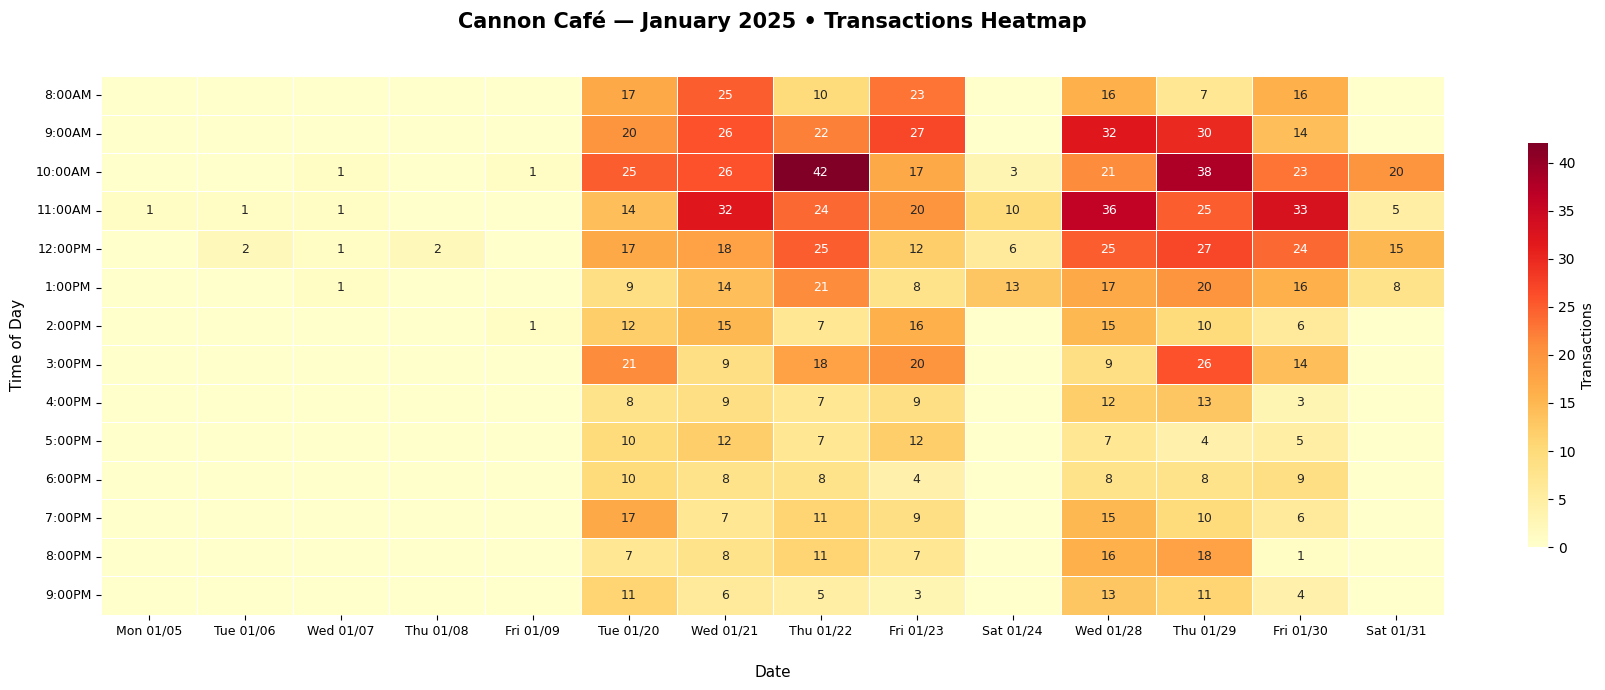

Saved: heatmap_cannon_jan2025.png


In [62]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# ================= CONFIG =================
path = "cannon_jan2025_transactions.xlsx"
title = "Cannon Café — January 2025 • Transactions Heatmap"

TIME_ORDER = [
    "8:00AM", "9:00AM", "10:00AM", "11:00AM",
    "12:00PM", "1:00PM", "2:00PM", "3:00PM", "4:00PM",
    "5:00PM", "6:00PM", "7:00PM", "8:00PM", "9:00PM"
]

# ================= LOAD =================
df = pd.read_excel(path, header=0)
df.columns = df.columns.str.strip()
df["Date_dt"] = pd.to_datetime(df["Date"])
df["Transactions"] = pd.to_numeric(df["Transactions"], errors="coerce")
df["Time"] = df["Time"].astype(str).str.strip()
df["DayLabel"] = df["Weekday"].str[:3] + " " + df["Date_dt"].dt.strftime("%m/%d")

# ================= FILTER: open days only =================
daily_totals = df.groupby("DayLabel")["Transactions"].sum()
open_days = daily_totals[daily_totals > 0].index.tolist()
df = df[df["DayLabel"].isin(open_days)]

# ================= PIVOT =================
pivot = df.pivot_table(
    index="Time",
    columns="DayLabel",
    values="Transactions",
    aggfunc="sum",
    fill_value=0
)

day_order = sorted(pivot.columns,
                   key=lambda x: pd.to_datetime(x.split()[1] + "/2025", format="%m/%d/%Y"))
pivot = pivot.reindex(index=TIME_ORDER, columns=day_order)

# ================= COLORS =================
cmap = mpl.colormaps["YlOrRd"].copy()
cmap.set_bad("#E0E0E0")

annot = pivot.map(lambda x: "" if pd.isna(x) or x == 0 else str(int(x)))

# ================= PLOT =================
num_days = len(day_order)
fig_width  = max(18, num_days * 0.9)
fig_height = 7

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

sns.heatmap(
    pivot,
    ax=ax,
    cmap=cmap,
    linewidths=0.4,
    linecolor="white",
    annot=annot,
    fmt="",
    cbar_kws={"label": "Transactions", "shrink": 0.75},
    vmin=0,
    vmax=pivot.max().max() if not pivot.empty else 1,
    annot_kws={"size": 9},
)

# ================= LABELS =================
ax.set_title(title, fontsize=15, weight="bold", pad=35)
ax.set_xlabel("Date", fontsize=11, labelpad=20)
ax.set_ylabel("Time of Day", fontsize=11, labelpad=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.subplots_adjust(bottom=0.3)
plt.tight_layout()
plt.savefig("heatmap_cannon_jan2025.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: heatmap_cannon_jan2025.png")

# ZAROS DATA

Total days in dataset: 22
Days actually open (with transactions): 7
Closed days (filtered out): 15


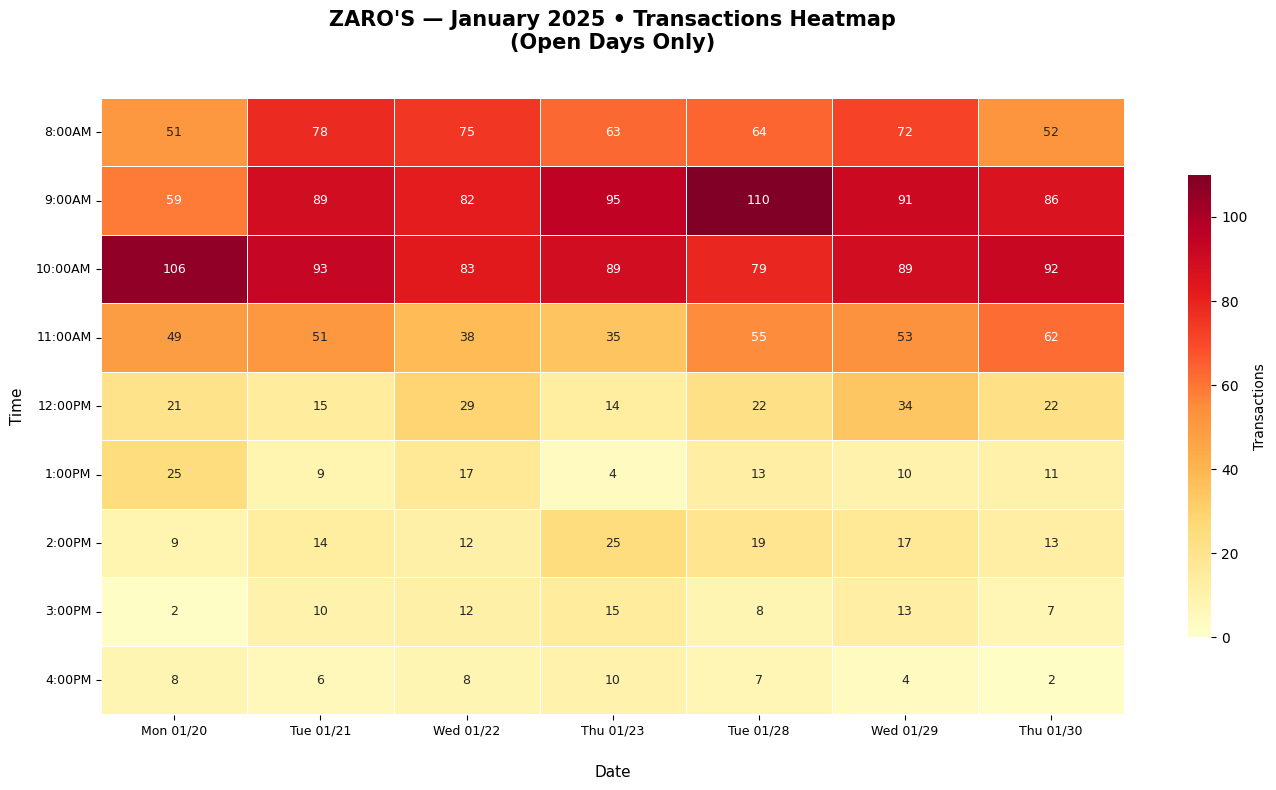


ZARO'S - JANUARY 2025 (OPEN DAYS ONLY)
Total transactions: 2,508
Number of open days: 7
Average per open day: 358
Peak day: Wed 01/29 (383)
Peak hour: 10:00AM (631)

Top 5 Busiest Days:
  Wed 01/29: 383
  Tue 01/28: 377
  Tue 01/21: 365
  Wed 01/22: 356
  Thu 01/23: 350

Transactions by Hour:
  10:00AM: 631
  9:00AM: 612
  8:00AM: 455
  11:00AM: 343
  12:00PM: 157
  2:00PM: 109
  1:00PM: 89
  3:00PM: 67
  4:00PM: 45

----------------------------------------
Daily Totals:
  Mon 01/20: 330
  Tue 01/21: 365
  Wed 01/22: 356
  Thu 01/23: 350
  Tue 01/28: 377
  Wed 01/29: 383
  Thu 01/30: 347


In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches

# ================= CONFIG =================
path = "/content/zaros_jan2025_transactions_TIdyDYZAROS.xlsx"
title = "ZARO'S — January 2025 • Transactions Heatmap\n(Open Days Only)"

TIME_ORDER = [
    "8:00AM", "9:00AM", "10:00AM", "11:00AM",
    "12:00PM", "1:00PM", "2:00PM", "3:00PM", "4:00PM"
]

# ================= LOAD =================
df = pd.read_excel(path, sheet_name=0)
df.columns = ['Weekday', 'Date', 'Time', 'Transactions', 'Notes']
df["Date_dt"] = pd.to_datetime(df["Date"])
df["Transactions"] = pd.to_numeric(df["Transactions"], errors="coerce")
df["Time"] = df["Time"].astype(str).str.strip()
df["Notes"] = df["Notes"].astype(str).str.strip().replace("nan", "")
df["DayLabel"] = df["Date_dt"].dt.strftime("%a %m/%d")

# ================= FILTER OUT CLOSED DAYS =================
# Calculate daily totals
daily_totals = df.groupby('DayLabel')['Transactions'].sum().reset_index()
daily_totals.columns = ['DayLabel', 'DailyTotal']

# Get days that were actually open (daily total > 0)
open_days = daily_totals[daily_totals['DailyTotal'] > 0]['DayLabel'].tolist()

print(f"Total days in dataset: {len(daily_totals)}")
print(f"Days actually open (with transactions): {len(open_days)}")
print(f"Closed days (filtered out): {len(daily_totals) - len(open_days)}")

# Filter dataframe to only include open days
df_filtered = df[df['DayLabel'].isin(open_days)].copy()

# ================= CLASSIFY NOTES FOR OPEN DAYS ONLY =================
CLOSED_KW = ["CLOSED", "WINTER BREAK", "MLK", "SNOW"]
SNOW_KW = ["SNOW"]
MLK_KW = ["MLK"]

def note_type(note):
    n = note.upper()
    if "SNOW" in n:
        return "snow"
    if "MLK" in n:
        return "mlk"
    if any(k in n for k in ["WINTER BREAK"]):
        return "closed"
    return ""

df_filtered["NoteType"] = df_filtered["Notes"].apply(note_type)

# ================= PIVOT =================
pivot = df_filtered.pivot_table(
    index="Time",
    columns="DayLabel",
    values="Transactions",
    aggfunc="sum",
    fill_value=0
)

# Order by date
day_order = sorted(pivot.columns, key=lambda x: pd.to_datetime(x.split()[1] + '/2025', format='%m/%d/%Y'))
pivot = pivot.reindex(index=TIME_ORDER, columns=day_order)

# Get note types for open days
day_notetype = {}
for day in day_order:
    day_notes = df_filtered[df_filtered['DayLabel'] == day]['NoteType'].unique()
    day_notetype[day] = day_notes[0] if len(day_notes) > 0 and day_notes[0] != '' else ''

# ================= COLORS =================
cmap = mpl.colormaps["YlOrRd"].copy()
cmap.set_bad("#E0E0E0")

# Create annotations - show actual numbers
annot = pivot.map(lambda x: "" if pd.isna(x) or x == 0 else str(int(x)))

# ================= PLOT WITH MORE SPACE BETWEEN DATES =================
num_days = len(day_order)
fig_width = max(14, num_days * 0.9)  # 0.9 inches per day
fig_height = 8

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

sns.heatmap(
    pivot,
    ax=ax,
    cmap=cmap,
    linewidths=0.5,
    linecolor="white",
    annot=annot,
    fmt="",
    cbar_kws={"label": "Transactions", "shrink": 0.75},
    vmin=0,
    vmax=pivot.max().max() if not pivot.empty else 1,
    annot_kws={"size": 9}
)

# ================= SPECIAL DAY HIGHLIGHTS =================
for i, day in enumerate(day_order):
    ntype = day_notetype.get(day, '')
    if ntype == "snow":
        ax.axvspan(i, i + 1, color="#ADD8E6", alpha=0.25, zorder=0)
        ax.text(i + 0.5, -0.3, "❄ Snow", ha="center", va="center",
                fontsize=8, color="#1a6fa0", rotation=0,
                transform=ax.get_xaxis_transform(), clip_on=False)
    elif ntype == "mlk":
        ax.axvspan(i, i + 1, color="#D3D3D3", alpha=0.3, zorder=0)
        ax.text(i + 0.5, -0.3, "MLK Day", ha="center", va="center",
                fontsize=8, color="#555555", weight="bold",
                transform=ax.get_xaxis_transform(), clip_on=False)

# ================= LABELS WITH MORE SPACE =================
ax.set_title(title, fontsize=15, weight="bold", pad=35)
ax.set_xlabel("Date", fontsize=11, labelpad=20)
ax.set_ylabel("Time", fontsize=11, labelpad=8)

# Make x-axis labels straight (no rotation)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center", fontsize=9)

# Add more bottom padding for straight text
plt.subplots_adjust(bottom=0.25)

# Show every other label if still crowded
if num_days > 15:
    for i, label in enumerate(ax.xaxis.get_ticklabels()):
        if i % 2 != 0:  # Hide every other label
            label.set_visible(False)

ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

# ================= NO LEGEND =================
# Legend removed as requested

plt.tight_layout()
plt.savefig("zaros_jan2025_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# ===== PRINT SUMMARY =====
print("\n" + "="*60)
print("ZARO'S - JANUARY 2025 (OPEN DAYS ONLY)")
print("="*60)
print(f"Total transactions: {pivot.sum().sum():,.0f}")
print(f"Number of open days: {len(day_order)}")
print(f"Average per open day: {pivot.sum().mean():,.0f}")
print(f"Peak day: {pivot.sum().idxmax()} ({pivot.sum().max():,.0f})")
print(f"Peak hour: {pivot.sum(axis=1).idxmax()} ({pivot.sum(axis=1).max():,.0f})")

print("\nTop 5 Busiest Days:")
for day, total in pivot.sum().sort_values(ascending=False).head(5).items():
    note = f" ({day_notetype.get(day, '')})" if day_notetype.get(day, '') else ""
    print(f"  {day}{note}: {total:,.0f}")

print("\nTransactions by Hour:")
for hour, total in pivot.sum(axis=1).sort_values(ascending=False).items():
    print(f"  {hour}: {total:,.0f}")

# Daily totals for each open day
print("\n" + "-"*40)
print("Daily Totals:")
for day in day_order:
    total = pivot[day].sum()
    note = day_notetype.get(day, '')
    note_str = f" ({note})" if note else ""
    print(f"  {day}{note_str}: {total:,.0f}")

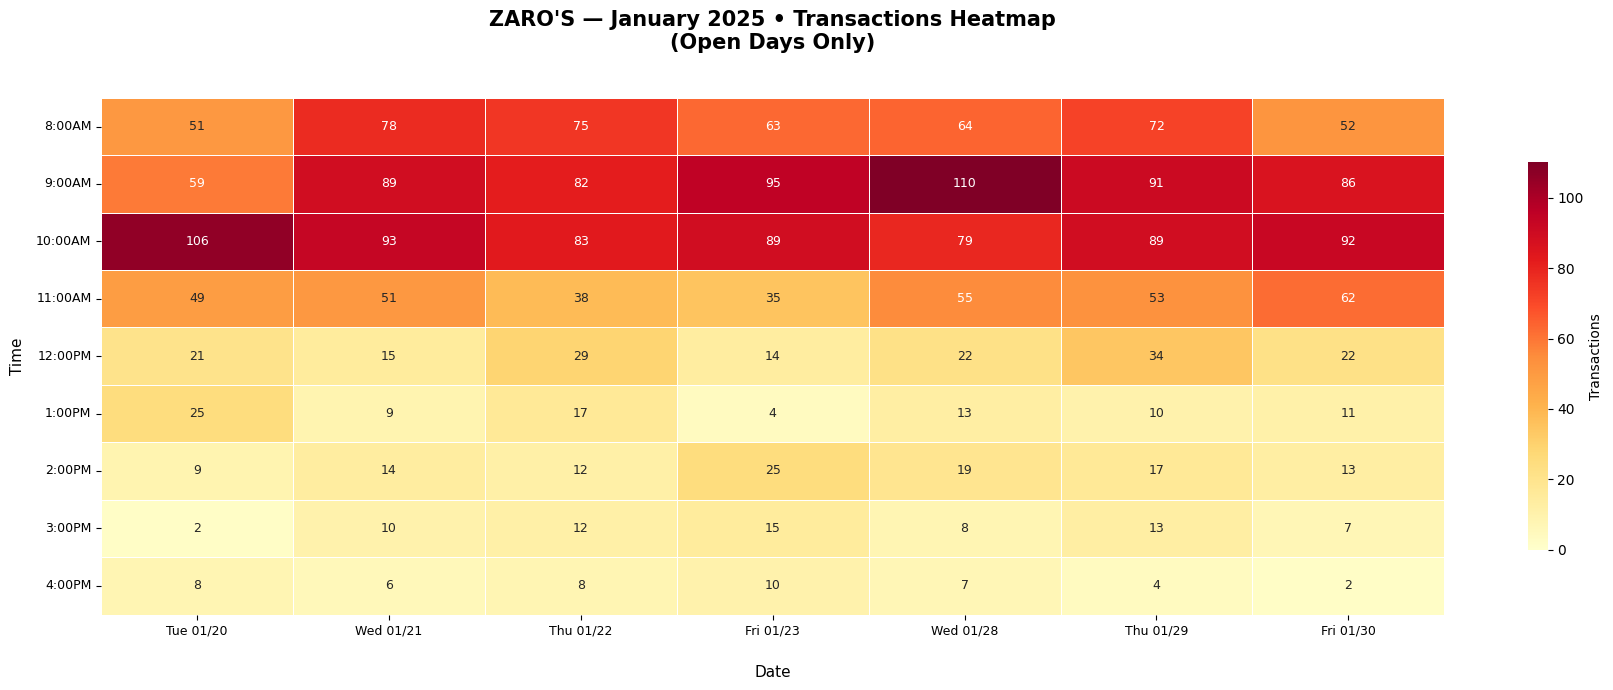

Saved: heatmap_zaros_jan2025.png


In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# ================= CONFIG =================
path = "/content/zaros_jan2025_transactions_TIdyDYZAROS.xlsx"
title = "ZARO'S — January 2025 • Transactions Heatmap\n(Open Days Only)"

TIME_ORDER = [
    "8:00AM", "9:00AM", "10:00AM", "11:00AM",
    "12:00PM", "1:00PM", "2:00PM", "3:00PM", "4:00PM"
]

# ================= LOAD =================
df = pd.read_excel(path, sheet_name=0)
df.columns = ['Weekday', 'Date', 'Time', 'Transactions', 'Notes']
df["Date_dt"] = pd.to_datetime(df["Date"])
df["Transactions"] = pd.to_numeric(df["Transactions"], errors="coerce")
df["Time"] = df["Time"].astype(str).str.strip()
df["Notes"] = df["Notes"].astype(str).str.strip().replace("nan", "")

# Use Weekday column from data (not strftime) to get correct label
df["DayLabel"] = df["Weekday"].str[:3] + " " + df["Date_dt"].dt.strftime("%m/%d")

# ================= FILTER: open days only =================
daily_totals = df.groupby("DayLabel")["Transactions"].sum()
open_days = daily_totals[daily_totals > 0].index.tolist()
df = df[df["DayLabel"].isin(open_days)]

# ================= PIVOT =================
pivot = df.pivot_table(
    index="Time",
    columns="DayLabel",
    values="Transactions",
    aggfunc="sum",
    fill_value=0
)

day_order = sorted(pivot.columns,
                   key=lambda x: pd.to_datetime(x.split()[1] + "/2025", format="%m/%d/%Y"))
pivot = pivot.reindex(index=TIME_ORDER, columns=day_order)

# ================= COLORS =================
cmap = mpl.colormaps["YlOrRd"].copy()
cmap.set_bad("#E0E0E0")

annot = pivot.map(lambda x: "" if pd.isna(x) or x == 0 else str(int(x)))

# ================= PLOT =================
num_days = len(day_order)
fig_width  = max(18, num_days * 0.9)
fig_height = 7

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

sns.heatmap(
    pivot,
    ax=ax,
    cmap=cmap,
    linewidths=0.4,
    linecolor="white",
    annot=annot,
    fmt="",
    cbar_kws={"label": "Transactions", "shrink": 0.75},
    vmin=0,
    vmax=pivot.max().max() if not pivot.empty else 1,
    annot_kws={"size": 9},
)

# ================= LABELS =================
ax.set_title(title, fontsize=15, weight="bold", pad=35)
ax.set_xlabel("Date", fontsize=11, labelpad=20)
ax.set_ylabel("Time", fontsize=11, labelpad=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.subplots_adjust(bottom=0.3)
plt.tight_layout()
plt.savefig("heatmap_zaros_jan2025.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: heatmap_zaros_jan2025.png")

# CREATE DATA HEATMAP

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


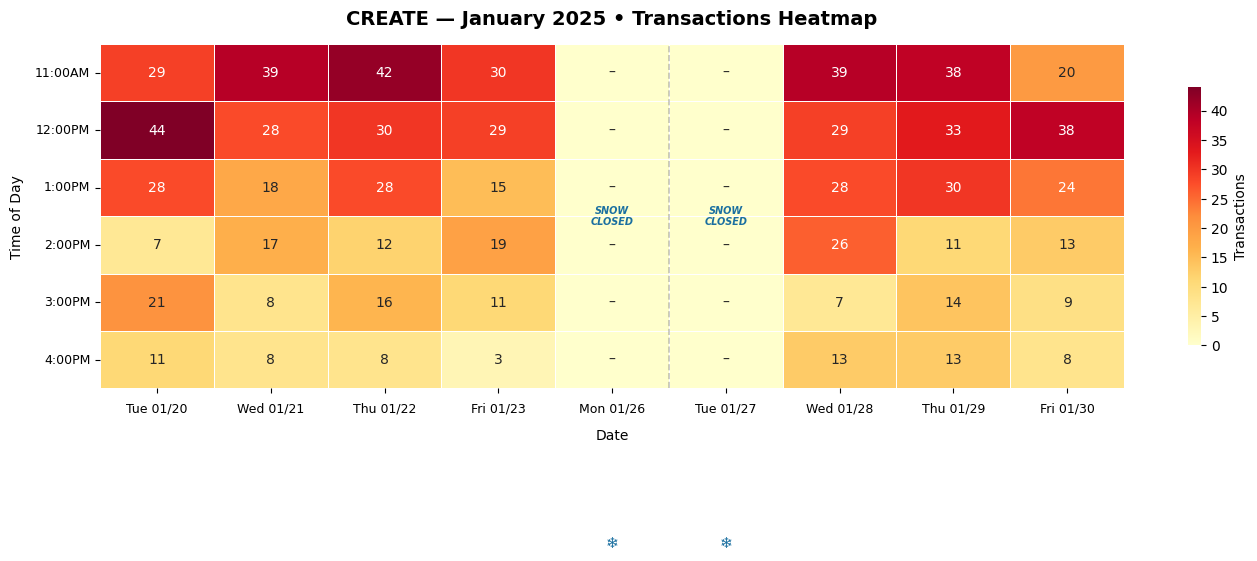

Saved: heatmap_create_jan2025.png


In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# ================= CONFIG =================
path = "create_jan2025_transactions.xlsx"
title = "CREATE — January 2025 • Transactions Heatmap"

TIME_ORDER = [
    "11:00AM", "12:00PM", "1:00PM", "2:00PM", "3:00PM", "4:00PM"
]

# ================= LOAD =================
df = pd.read_excel(path, header=0)
df.columns = df.columns.str.strip()
df["Date_dt"] = pd.to_datetime(df["Date"])
df["Transactions"] = pd.to_numeric(df["Transactions"], errors="coerce")
df["Time"] = df["Time"].astype(str).str.strip()
df["Notes"] = df["Notes"].astype(str).str.strip().replace("nan", "")

# Use Weekday column from data (not strftime) — avoids off-by-one day name bug
df["DayLabel"] = df["Weekday"].str[:3] + " " + df["Date_dt"].dt.strftime("%m/%d")

# ================= CLASSIFY NOTES =================
def note_type(note):
    n = note.upper()
    if "SNOW" in n:    return "snow"
    if "MLK" in n:     return "mlk"
    if "WINTER" in n:  return "closed"
    return ""

df["NoteType"] = df["Notes"].apply(note_type)

# Drop 5:00PM — always empty
df = df[df["Time"] != "5:00PM"]

# ================= FILTER DAYS =================
snow_days = df[df["NoteType"] == "snow"]["DayLabel"].unique()
has_data  = df[df["Transactions"].notna() & (df["Transactions"] > 0)]["DayLabel"].unique()
keep_days = set(has_data) | set(snow_days)

df.loc[df["NoteType"].isin(["closed", "mlk", "snow"]), "Transactions"] = np.nan

# ================= PIVOT =================
pivot = df.pivot_table(
    index="Time",
    columns="DayLabel",
    values="Transactions",
    aggfunc="sum"
)

day_order = (
    df[["DayLabel", "Date_dt"]]
    .drop_duplicates()
    .sort_values("Date_dt")
    .loc[lambda x: x["DayLabel"].isin(keep_days), "DayLabel"]
)
day_list = list(day_order)
pivot = pivot.reindex(index=TIME_ORDER, columns=day_list)

# ================= DAY NOTE LOOKUP =================
day_notetype = (
    df[df["NoteType"] != ""]
    .groupby("DayLabel")["NoteType"]
    .first()
    .to_dict()
)

# ================= COLORS =================
cmap = mpl.colormaps["YlOrRd"].copy()
cmap.set_bad("#E8E8E8")

annot = pivot.map(lambda x: "" if pd.isna(x) else (str(int(x)) if x > 0 else "–"))
mask  = pivot.isna()

# ================= PLOT =================
n_cols = len(day_list)
n_rows = len(TIME_ORDER)
fig_width  = max(14, n_cols * 1.4)
fig_height = max(6,  n_rows * 0.85)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

sns.heatmap(
    pivot,
    ax=ax,
    cmap=cmap,
    linewidths=0.5,
    linecolor="white",
    annot=annot,
    fmt="",
    mask=mask,
    cbar_kws={"label": "Transactions", "shrink": 0.75},
    vmin=0,
    vmax=pivot.max().max() if not pivot.empty else 1,
    annot_kws={"size": 10},
)

# Grey overlay for NaN cells
sns.heatmap(
    pivot.isna().astype(float).replace(0, np.nan),
    ax=ax,
    cmap=mpl.colors.ListedColormap(["#D0D0D0"]),
    linewidths=0.5,
    linecolor="white",
    cbar=False,
    mask=~mask,
)

# ================= SPECIAL COLUMN LABELS =================
for day, ntype in day_notetype.items():
    if day not in day_list:
        continue
    col_idx = day_list.index(day)
    if ntype == "snow":
        ax.axvspan(col_idx, col_idx + 1, color="#ADD8E6", alpha=0.20, zorder=0)
        ax.text(col_idx + 0.5, -0.45, "❄", ha="center", va="center",
                fontsize=11, color="#1a6fa0",
                transform=ax.get_xaxis_transform(), clip_on=False)
        ax.text(col_idx + 0.5, n_rows / 2, "SNOW\nCLOSED",
                ha="center", va="center", fontsize=7,
                color="#1a6fa0", fontweight="bold", style="italic")
    elif ntype == "mlk":
        ax.axvspan(col_idx, col_idx + 1, color="#FFE599", alpha=0.30, zorder=0)
        ax.text(col_idx + 0.5, n_rows / 2, "MLK\nCLOSED",
                ha="center", va="center", fontsize=7,
                color="#7a5c00", fontweight="bold", style="italic")

# ================= WEEK DIVIDERS =================
date_lookup = df[["DayLabel","Date_dt"]].drop_duplicates().set_index("DayLabel")["Date_dt"].to_dict()
for i, label in enumerate(day_list):
    dt = date_lookup[label]
    if dt.weekday() == 0 and i > 0:
        ax.axvline(x=i, color="#888888", linewidth=1.2, linestyle="--", alpha=0.5)

# ================= LABELS =================
ax.set_title(title, fontsize=14, weight="bold", pad=14)
ax.set_xlabel("Date", fontsize=10, labelpad=10)
ax.set_ylabel("Time of Day", fontsize=10, labelpad=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.tick_params(axis="x", pad=6)

plt.subplots_adjust(bottom=0.2)
plt.tight_layout()
plt.savefig("heatmap_create_jan2025.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: heatmap_create_jan2025.png")

Yellas

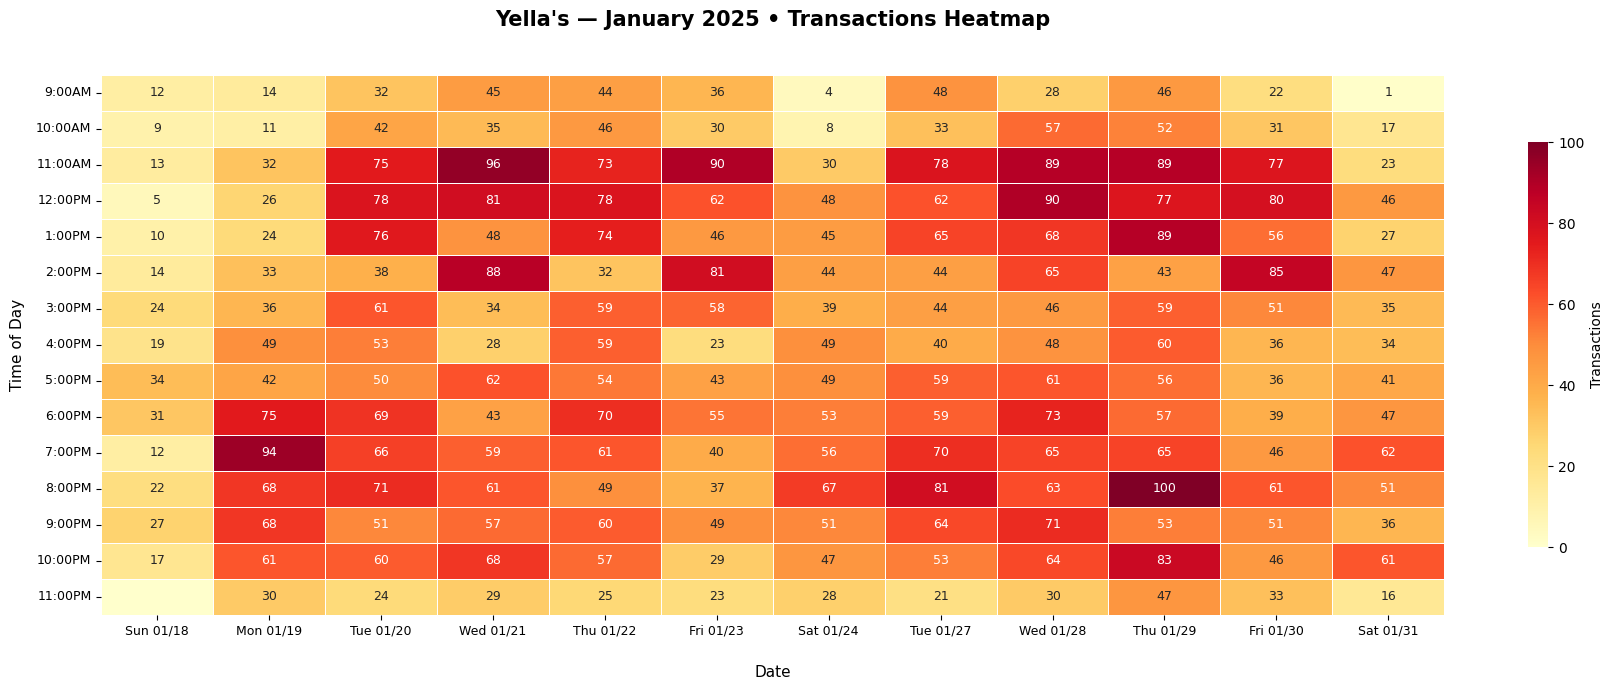

Saved: heatmap_yellas_jan2025.png


In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# ================= CONFIG =================
path = "/content/Copy of yellas_jan2025_tratidynsactions.xlsx"
title = "Yella's — January 2025 • Transactions Heatmap"

TIME_ORDER = [
    "9:00AM", "10:00AM", "11:00AM", "12:00PM", "1:00PM", "2:00PM",
    "3:00PM", "4:00PM", "5:00PM", "6:00PM", "7:00PM", "8:00PM",
    "9:00PM", "10:00PM", "11:00PM"
]

# ================= LOAD =================
df = pd.read_excel(path, header=0)
df.columns = df.columns.str.strip()
df["Date_dt"] = pd.to_datetime(df["Date"])
df["Transactions"] = pd.to_numeric(df["Transactions"], errors="coerce")
df["Time"] = df["Time"].astype(str).str.strip()

# Use Weekday column from data (not strftime) — avoids off-by-one day name bug
df["DayLabel"] = df["Weekday"].str[:3] + " " + df["Date_dt"].dt.strftime("%m/%d")

# ================= FILTER: open days only =================
daily_totals = df.groupby("DayLabel")["Transactions"].sum()
open_days = daily_totals[daily_totals > 0].index.tolist()
df = df[df["DayLabel"].isin(open_days)]

# ================= PIVOT =================
pivot = df.pivot_table(
    index="Time",
    columns="DayLabel",
    values="Transactions",
    aggfunc="sum",
    fill_value=0
)

day_order = sorted(pivot.columns,
                   key=lambda x: pd.to_datetime(x.split()[1] + "/2025", format="%m/%d/%Y"))
pivot = pivot.reindex(index=TIME_ORDER, columns=day_order)

# ================= COLORS =================
cmap = mpl.colormaps["YlOrRd"].copy()
cmap.set_bad("#E0E0E0")

annot = pivot.map(lambda x: "" if pd.isna(x) or x == 0 else str(int(x)))

# ================= PLOT =================
num_days = len(day_order)
fig_width  = max(18, num_days * 0.9)
fig_height = 7

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

sns.heatmap(
    pivot,
    ax=ax,
    cmap=cmap,
    linewidths=0.4,
    linecolor="white",
    annot=annot,
    fmt="",
    cbar_kws={"label": "Transactions", "shrink": 0.75},
    vmin=0,
    vmax=pivot.max().max() if not pivot.empty else 1,
    annot_kws={"size": 9},
)

# ================= LABELS =================
ax.set_title(title, fontsize=15, weight="bold", pad=35)
ax.set_xlabel("Date", fontsize=11, labelpad=20)
ax.set_ylabel("Time of Day", fontsize=11, labelpad=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.subplots_adjust(bottom=0.3)
plt.tight_layout()
plt.savefig("heatmap_yellas_jan2025.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: heatmap_yellas_jan2025.png")

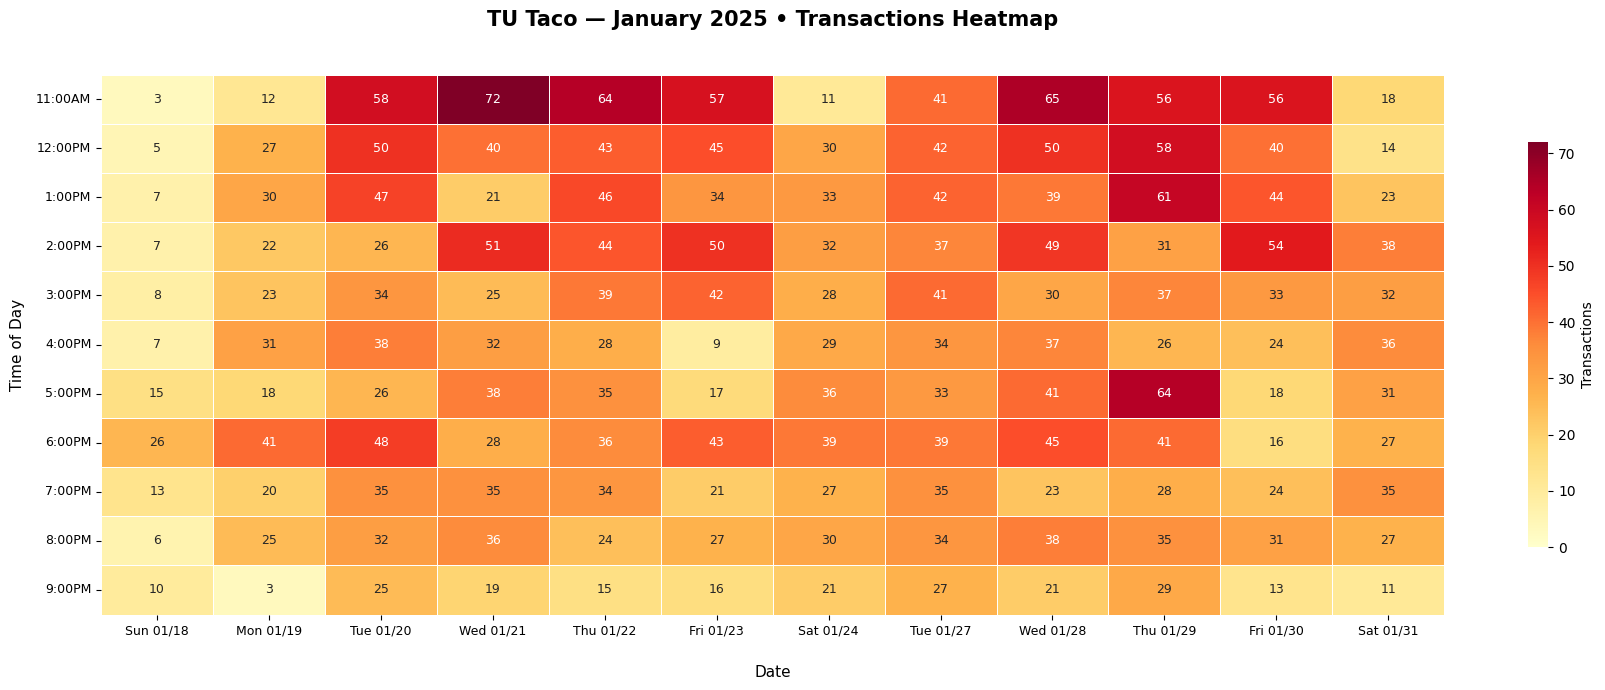

Saved: heatmap_tutaco_jan2025.png


In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# ================= CONFIG =================
path = "/content/tutaco_jan2025_transactions.xlsx"
title = "TU Taco — January 2025 • Transactions Heatmap"

TIME_ORDER = [
    "11:00AM", "12:00PM", "1:00PM", "2:00PM", "3:00PM", "4:00PM",
    "5:00PM", "6:00PM", "7:00PM", "8:00PM", "9:00PM"
]

# ================= LOAD =================
df = pd.read_excel(path, header=0)
df.columns = df.columns.str.strip()
df["Date_dt"] = pd.to_datetime(df["Date"])
df["Transactions"] = pd.to_numeric(df["Transactions"], errors="coerce")
df["Time"] = df["Time"].astype(str).str.strip()

# Weekday column is +1 ahead of actual calendar (same as Yella's) — use it as source of truth
df["DayLabel"] = df["Weekday"].str[:3] + " " + df["Date_dt"].dt.strftime("%m/%d")

# ================= FILTER: open days only =================
daily_totals = df.groupby("DayLabel")["Transactions"].sum()
open_days = daily_totals[daily_totals > 0].index.tolist()
df = df[df["DayLabel"].isin(open_days)]

# ================= PIVOT =================
pivot = df.pivot_table(
    index="Time",
    columns="DayLabel",
    values="Transactions",
    aggfunc="sum",
    fill_value=0
)

day_order = sorted(pivot.columns,
                   key=lambda x: pd.to_datetime(x.split()[1] + "/2025", format="%m/%d/%Y"))
pivot = pivot.reindex(index=TIME_ORDER, columns=day_order)

# ================= COLORS =================
cmap = mpl.colormaps["YlOrRd"].copy()
cmap.set_bad("#E0E0E0")

annot = pivot.map(lambda x: "" if pd.isna(x) or x == 0 else str(int(x)))

# ================= PLOT =================
num_days = len(day_order)
fig_width  = max(18, num_days * 0.9)
fig_height = 7

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

sns.heatmap(
    pivot,
    ax=ax,
    cmap=cmap,
    linewidths=0.4,
    linecolor="white",
    annot=annot,
    fmt="",
    cbar_kws={"label": "Transactions", "shrink": 0.75},
    vmin=0,
    vmax=pivot.max().max() if not pivot.empty else 1,
    annot_kws={"size": 9},
)

# ================= LABELS =================
ax.set_title(title, fontsize=15, weight="bold", pad=35)
ax.set_xlabel("Date", fontsize=11, labelpad=20)
ax.set_ylabel("Time of Day", fontsize=11, labelpad=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.subplots_adjust(bottom=0.3)
plt.tight_layout()
plt.savefig("heatmap_tutaco_jan2025.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: heatmap_tutaco_jan2025.png")

POM AND HONEY

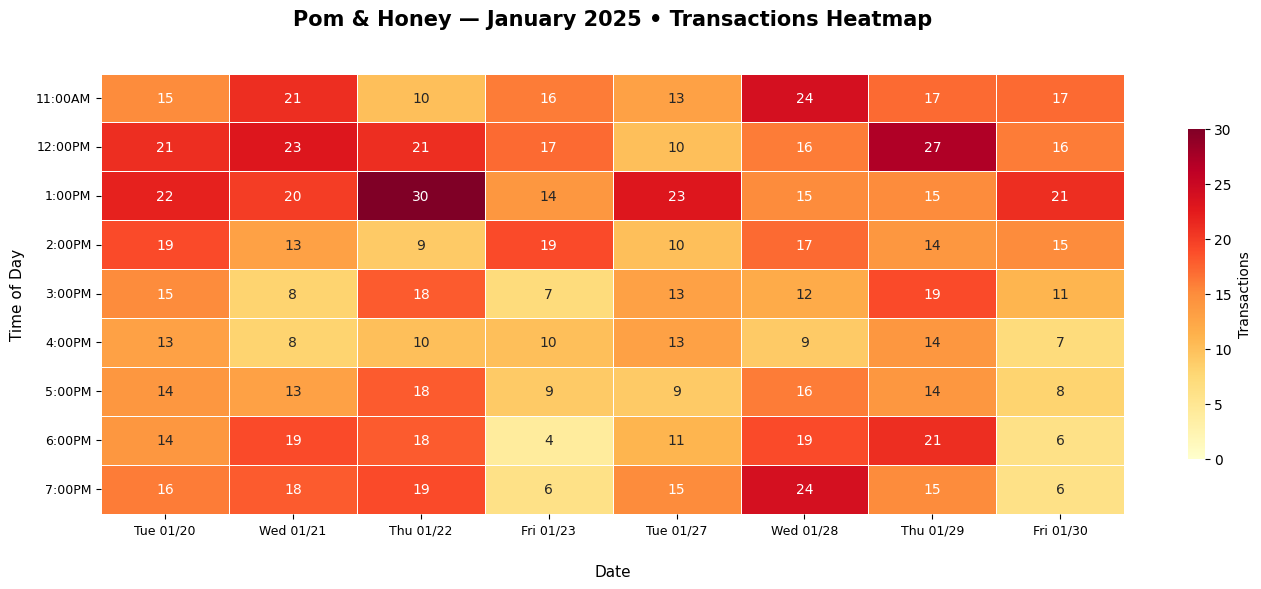

Saved: heatmap_pomhoney_jan2025.png


In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# ================= CONFIG =================
path = "/content/pomhoney_jan2025_transactions.xlsx"
title = "Pom & Honey — January 2025 • Transactions Heatmap"

TIME_ORDER = [
    "11:00AM", "12:00PM", "1:00PM", "2:00PM",
    "3:00PM", "4:00PM", "5:00PM", "6:00PM", "7:00PM"
]

# ================= LOAD =================
df = pd.read_excel(path, header=0)
df.columns = df.columns.str.strip()
df["Date_dt"] = pd.to_datetime(df["Date"])
df["Transactions"] = pd.to_numeric(df["Transactions"], errors="coerce")
df["Time"] = df["Time"].astype(str).str.strip()

# Weekday column is +1 ahead of actual calendar — use as source of truth
df["DayLabel"] = df["Weekday"].str[:3] + " " + df["Date_dt"].dt.strftime("%m/%d")

# ================= FILTER: open days only =================
daily_totals = df.groupby("DayLabel")["Transactions"].sum()
open_days = daily_totals[daily_totals > 0].index.tolist()
df = df[df["DayLabel"].isin(open_days)]

# ================= PIVOT =================
pivot = df.pivot_table(
    index="Time",
    columns="DayLabel",
    values="Transactions",
    aggfunc="sum",
    fill_value=0
)

day_order = sorted(pivot.columns,
                   key=lambda x: pd.to_datetime(x.split()[1] + "/2025", format="%m/%d/%Y"))
pivot = pivot.reindex(index=TIME_ORDER, columns=day_order)

# ================= COLORS =================
cmap = mpl.colormaps["YlOrRd"].copy()
cmap.set_bad("#E0E0E0")

annot = pivot.map(lambda x: "" if pd.isna(x) or x == 0 else str(int(x)))

# ================= PLOT =================
num_days = len(day_order)
fig_width  = max(14, num_days * 1.4)
fig_height = 6

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

sns.heatmap(
    pivot,
    ax=ax,
    cmap=cmap,
    linewidths=0.4,
    linecolor="white",
    annot=annot,
    fmt="",
    cbar_kws={"label": "Transactions", "shrink": 0.75},
    vmin=0,
    vmax=pivot.max().max() if not pivot.empty else 1,
    annot_kws={"size": 10},
)

# ================= LABELS =================
ax.set_title(title, fontsize=15, weight="bold", pad=35)
ax.set_xlabel("Date", fontsize=11, labelpad=20)
ax.set_ylabel("Time of Day", fontsize=11, labelpad=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.subplots_adjust(bottom=0.3)
plt.tight_layout()
plt.savefig("heatmap_pomhoney_jan2025.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: heatmap_pomhoney_jan2025.png")

PICCCOLAAA

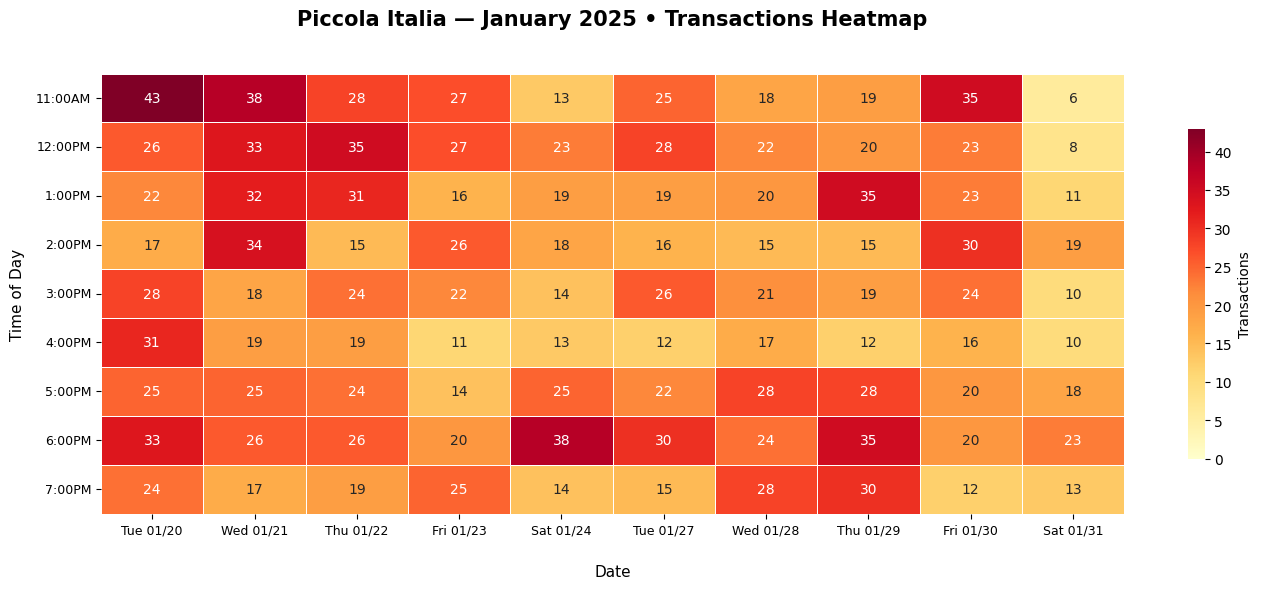

Saved: heatmap_piccola_jan2025.png


In [67]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# ================= CONFIG =================
path = "/content/piccola_jan2025_transactions.xlsx"
title = "Piccola Italia — January 2025 • Transactions Heatmap"

TIME_ORDER = [
    "11:00AM", "12:00PM", "1:00PM", "2:00PM",
    "3:00PM", "4:00PM", "5:00PM", "6:00PM", "7:00PM"
]

# ================= LOAD =================
df = pd.read_excel(path, header=0)
df.columns = df.columns.str.strip()
df["Date_dt"] = pd.to_datetime(df["Date"])
df["Transactions"] = pd.to_numeric(df["Transactions"], errors="coerce")
df["Time"] = df["Time"].astype(str).str.strip()

# Weekday column is +1 ahead of actual calendar — use as source of truth
df["DayLabel"] = df["Weekday"].str[:3] + " " + df["Date_dt"].dt.strftime("%m/%d")

# ================= FILTER: open days only =================
daily_totals = df.groupby("DayLabel")["Transactions"].sum()
open_days = daily_totals[daily_totals > 0].index.tolist()
df = df[df["DayLabel"].isin(open_days)]

# ================= PIVOT =================
pivot = df.pivot_table(
    index="Time",
    columns="DayLabel",
    values="Transactions",
    aggfunc="sum",
    fill_value=0
)

day_order = sorted(pivot.columns,
                   key=lambda x: pd.to_datetime(x.split()[1] + "/2025", format="%m/%d/%Y"))
pivot = pivot.reindex(index=TIME_ORDER, columns=day_order)

# ================= COLORS =================
cmap = mpl.colormaps["YlOrRd"].copy()
cmap.set_bad("#E0E0E0")

annot = pivot.map(lambda x: "" if pd.isna(x) or x == 0 else str(int(x)))

# ================= PLOT =================
num_days = len(day_order)
fig_width  = max(14, num_days * 1.4)
fig_height = 6

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

sns.heatmap(
    pivot,
    ax=ax,
    cmap=cmap,
    linewidths=0.4,
    linecolor="white",
    annot=annot,
    fmt="",
    cbar_kws={"label": "Transactions", "shrink": 0.75},
    vmin=0,
    vmax=pivot.max().max() if not pivot.empty else 1,
    annot_kws={"size": 10},
)

# ================= LABELS =================
ax.set_title(title, fontsize=15, weight="bold", pad=35)
ax.set_xlabel("Date", fontsize=11, labelpad=20)
ax.set_ylabel("Time of Day", fontsize=11, labelpad=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.subplots_adjust(bottom=0.3)
plt.tight_layout()
plt.savefig("heatmap_piccola_jan2025.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: heatmap_piccola_jan2025.png")